## 0. IMPORT AND INITIAL SETUP

In [42]:
import numpy as np
import pandas as pd
import ast
import copy
import json
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

def clear_gpu():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [3]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH =  "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

## 1. DATASET DESCRIPTION AND OVERVIEW

The Soil Moisture Active Passive (SMAP) dataset is a real-world, multivariate time-series dataset provided by NASA. While the SMAP satellite itself is an Earth observation observatory designed to measure surface soil moisture and freeze-thaw states, the data utilized in this project does not represent the scientific radar or radiometer measurements. Instead, it consists entirely of the spacecraft's internal housekeeping and operational telemetry. 

This telemetry data acts as the "nervous system" of the satellite. It represents a continuous stream of sensor readings monitoring the health and status of various onboard subsystems, including power supply voltages, thermal variations, radiation readings, and mechanical currents. Crucially, these continuous analog signals are often accompanied by discrete operational flags, which represent binary commands sent by ground control or automatic state shifts within the spacecraft's software. 

NASA conceived and released this dataset specifically to advance the research of machine learning algorithms for automated spacecraft monitoring. The anomalies present in the data are not synthetic or artificially injected; they represent genuine "Incident Surprise Anomalies" (ISAs) and unexpected physical behaviors encountered during the actual mission. To provide a highly reliable ground truth, these anomalous sequences were meticulously identified, verified, and labeled by expert NASA flight engineers based on historical mission logs.

Because these anomalies are highly contextual and embedded within dense, noisy, and complex operational regimes, understanding exactly how they are structured and signaled in the ground truth is a critical first step. The following section details the format of the anomaly labels provided by NASA and visually plots a real anomalous sequence, illustrating precisely how these unexpected behaviors manifest within the raw telemetry before any modeling takes place.

In [4]:
df_anomalies = pd.read_csv(LABELS)
df_anomalies.info()
df_anomalies.head(12)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


**Description of Labels:**
- **`channel_id`**: The unique identifier related to a specific telemetry stream acquired by the spacecraft.
- **`spacecraft`**: The origin of the data, which can be either SMAP (Soil Moisture Active Passive) or MSL (Mars Science Laboratory, the Curiosity rover).
- **`anomaly_sequences`**: The specific temporal windows (start and end indices) corresponding to verified anomalies inside that telemetry stream.
- **`class`**: Indicates the nature of the anomaly. A *point anomaly* can often be identified by properly set static alarms or distance-based methods that ignore temporal information. Conversely, a *contextual anomaly* requires complex, sequence-aware methodologies (such as LSTMs or Transformers) to be detected.
- **`num_values`**: The total number of recorded observation timesteps ($T$) for that specific telemetry.

**Description of Train/Test Matrices:**
In practice, the data for each evaluated telemetry channel is structured as a **temporal matrix** of size $T \times 25$, where $T$ is the `num_values` and 25 represents the total number of parallel feature channels. 

Within this matrix, the first feature (index 0) invariably represents the primary continuous telemetry signal being monitored. The remaining 24 dimensions are auxiliary channels. These last channels encode critical contextual information—such as binary command flags sent by ground control, automated state transitions, or discrete operational modes. While these auxiliary vectors are inherently sparse (often containing long sequences of zeros representing an "off" state), they are fundamentally indispensable. They provide the precise operational context required by the models to evaluate whether a sudden fluctuation in the main continuous signal is a nominal response to a recent command, or a genuine contextual anomaly.

In [5]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print("Number of Available Telemetries: ", len(df_SMAP_anomalies['chan_id'].unique()))

Number of Available Telemetries:  54


### 1.1 Anomaly Visualization
Below, we visualize an example of an anomaly occurring on channel 0 of a randomly selected telemetry sequence.

Selected telemetry: E-8
Anomaly of telemetry: [[5400 6022]]


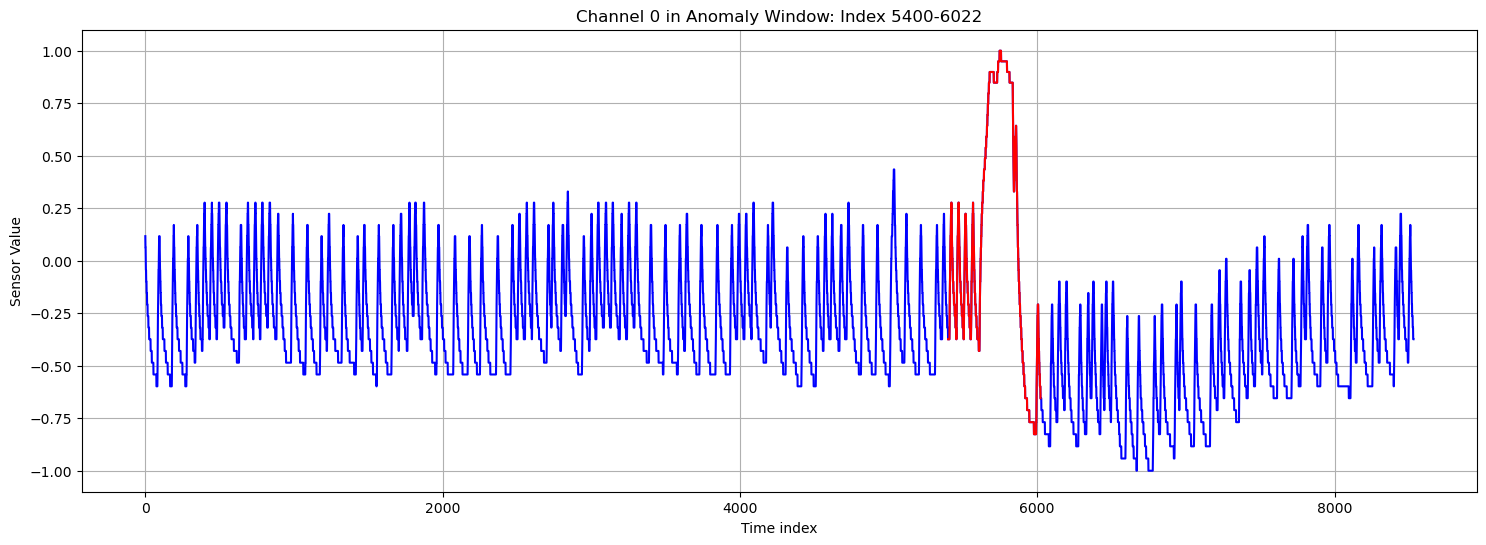

In [6]:
np.random.seed(10)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

The plot above unequivocally illustrates a **contextual anomaly** (highlighted in red) within a continuous telemetry stream (Channel 0). 

While the blue portion displays a nominal, rhythmic periodic oscillation, the red window (indices 5400-6022) reveals a prolonged structural deviation. The signal breaks its usual frequency, surges toward a value of 1.0, and drastically drops before attempting to restabilize into a highly disturbed pattern. 

This sequence is strictly contextual because the fault lies in the *evolution* of the waveform and its operational state, rather than a single out-of-bounds reading. To detect this anomaly early, a model must possess a "memory" of the expected temporal dynamics. Furthermore, a spike of this magnitude might be perfectly nominal if intentionally triggered by a ground command (e.g., activating an actuator). It is the critical *absence* of such a command flag in the auxiliary channels, combined with the disrupted temporal pattern, that ultimately flags this event as a genuine system failure. 

Because a simple static threshold alarm would only intercept the extreme apex of this curve while missing the onset, sequence-aware modeling is required. To highlight this distinction, the plot below demonstrates a contrasting **Point Anomaly**, where the error is simply an instantaneous, isolated spike entirely disconnected from the surrounding context.

Selected telemetry: R-1
Anomaly of telemetry: [[4510 4590]]


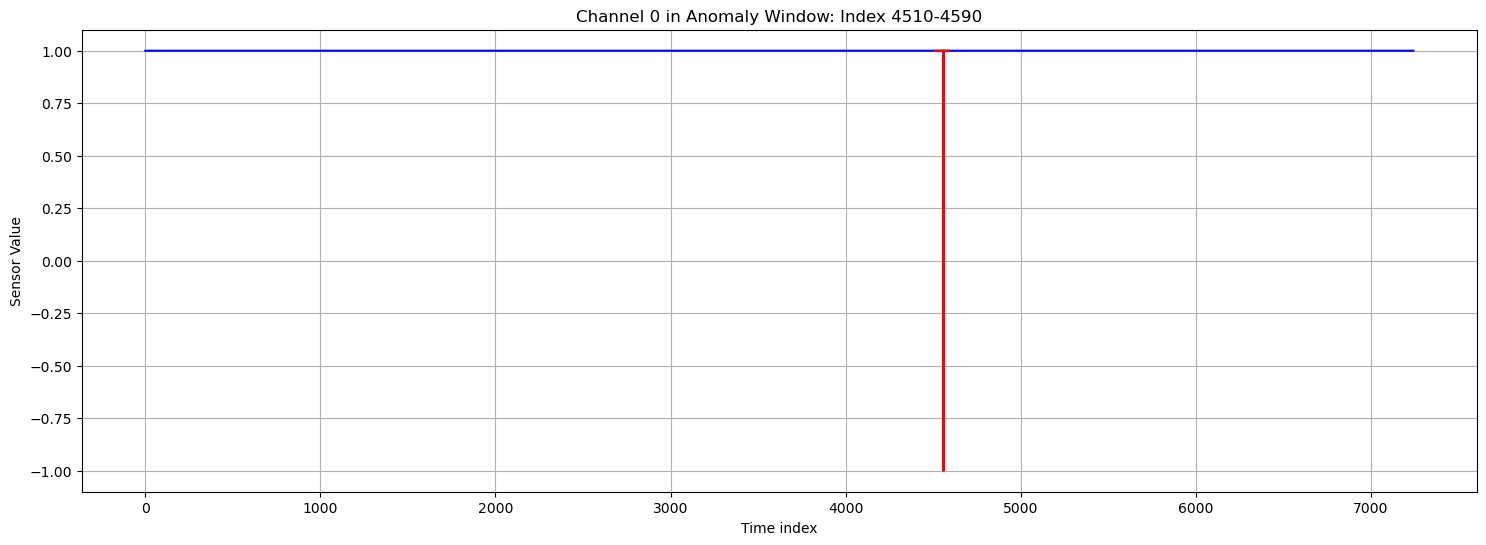

In [7]:
np.random.seed(4)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

In stark contrast to the previous example, the plot above illustrates a classic **Point Anomaly**. Here, the nominal telemetry (in blue) is perfectly static, maintaining a constant sensor value of 1.0. The anomaly (highlighted in red) manifests as a sudden, instantaneous plunge to -1.0 before immediately recovering to its baseline state.

Unlike contextual anomalies, this failure is entirely independent of the surrounding temporal dynamics or operational sequences. It is an isolated, out-of-bounds readingt. Because the value violently breaks the expected physical range in a single timestep, it is trivial to detect. A simple static threshold alarm (e.g., triggering if the value drops below 0.5) would perfectly isolate this event without requiring any historical memory or auxiliary command context. 

## 2. PREPROCESSING

Before feeding multivariate time-series data into our architectures, establishing a quantitative baseline of the dataset is a mandatory methodological step. Typically, raw spacecraft telemetry is highly heterogeneous, with different sensors operating on vastly different numerical scales. Processing such unbalanced data directly would cause severe gradient instability.


### 2.1 Exploratory Data Analysis
To assess the operational state of our input matrices, the following section systematically extracts and visualizes the core statistical properties such as mean, variance, and absolute ranges (min/max) for each telemetry channel. 

In [8]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.std(X, axis=0)
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training files shows that all channels contain 25 features and no missing or infinite values. Feature values are mostly bounded in [-1, 1] or [0, 1], suggesting that the dataset has already been normalized before release. For this reason, no additional standard scaling is applied in the main pipeline.

A relevant aspect is the presence of several constant features within many channels. At first, dimensionality reduction techniques such as PCA were considered to remove redundant or non-informative components. However, the constant features are kept in the final preprocessing strategy because they may still carry useful operational information: since some of these variables represent command signals, a flat signal can indicate the absence of a command and may therefore help the forecasting model distinguish normal operating conditions from anomalous behavior.

The training lengths are not uniform across channels, ranging from short sequences of a few hundred time steps to longer sequences close to 2880 time steps. This means that each channel should be treated independently, since the amount of available temporal context and the number of training windows differ substantially across telemetry streams.

### 2.2 Windowing Strategy

To allow the models to capture the temporal dynamics of the telemetry, the raw multivariate sequence is converted into a set of overlapping temporal windows. For each starting index $i$, the input sample $X_i$ extracts the subsequent $W$ observations (where $W$ is the `window_size`) across all available features. This shared input structure preserves the local temporal context and is identically utilized by all evaluated models, formulated as:

$$X_i = X[i : i + W, :]$$

While the input matrix $X_i$ remains strictly constant across all architectures to ensure a fair benchmark, the learning objective diverges based on the underlying paradigm. For forecasting-based models, the objective is to predict the future evolution of the primary telemetry signal. The target $y_i$ is defined as the next $P$ values (where $P$ is `n_predictions`) of feature $0$:

$$y_i = X[i + W : i + W + P, 0]$$

At test time, the anomaly score for these forecasting architectures is derived directly from the mismatch between this predicted future trajectory and the actual incoming observations. 

Conversely, for reconstruction-based models, future targets are completely discarded. The objective is instead to map the sequence into a latent space and reconstruct the input window itself, such that $X_i \rightarrow \hat{X}_i$. The anomaly score is then computed strictly from the reconstruction error. Anomalous behaviors inherently produce windows that deviate from the nominal manifold learned during training, making them significantly harder to accurately reconstruct.

To ensure high temporal resolution and pipeline compatibility, a sliding step of `stride = 1` is applied. This generates highly overlapping windows, maximizing the available training samples and providing a fine-grained, step-by-step anomaly score sequence during inference. During training, these extracted windows can be safely shuffled because the internal chronological order of the $W$ timesteps is intrinsically preserved within each $X_i$ matrix. During testing, however, windows are strictly evaluated in sequential order to perfectly align the resulting errors with the original time axis.

In [9]:
def make_forecasting_windows(X, window_size=250, n_predictions=10, stride=1):
    """
    Input:
        X[i : i + l_s]

    Target:
        X[i + l_s : i + l_s + n_predictions, 0]
    """

    X_windows = []
    y_windows = []

    for i in range(0, len(X) - window_size - n_predictions, stride):
        X_windows.append(X[i : i + window_size, :])
        y_windows.append(X[i + window_size : i + window_size + n_predictions, 0])

    return np.array(X_windows), np.array(y_windows)

### 2.3 Test Label Construction

The test labels are constructed directly from the originally annotated anomaly intervals provided by the dataset. For each evaluated telemetry channel, dedicated mapping functions clip the intervals to the valid sequence bounds and convert them into a dense binary vector matching the exact length of the raw test sequence. Specifically, nominal timesteps are designated as 0, while any timestep falling within a formally annotated anomalous interval is marked as 1. This conversion ensures that the ground truth is represented as a continuous temporal vector:

$$y_{raw} \in \{0, 1\}^{T_{test}}$$

where $T_{test}$ represents the total number of observations in the raw test sequence.

A fundamental challenge in this phase is the temporal delay introduced by the sliding windows: because the model requires an initial window of length $W$ to generate its first output, the resulting prediction sequence is shorter than the raw data. To resolve this misalignment without distorting the ground truth, a realignment is required but deferred to the end of the pipeline, where the final discrete predictions are simply shifted forward by $W$ steps. This solution ensures that both predictions and labels are evaluated on the exact same coordinate system.

In [10]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x


def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y


def align_anomalies(labels_df, channel_id, X_test_raw):
    """
    Return labels in raw test coordinates, not shifted coordinates.
    The prediction indices are shifted later by l_s inside dynamic thresholding.
    """
    y_raw = np.zeros(len(X_test_raw), dtype=int)

    intervals = labels_df[labels_df["chan_id"] == channel_id]["anomaly_sequences"]

    for seq in intervals:
        for start, end in seq:
            y_raw[start:end + 1] = 1

    return y_raw

In [11]:
df_SMAP_anomalies["anomaly_sequences"] = (df_SMAP_anomalies["anomaly_sequences"].apply(parse_anomaly_sequences))

In [12]:
window_size = 250
n_predictions = 10
stride = 1

X_train_data = {}
X_test_data = {}
y_train_data = {}
y_test_data = {}
labels_data = {}

for ch in smap_channels_ids:
    path_train = TRAIN_PATH + '/' + ch + '.npy'
    path_test = TEST_PATH + '/' + ch + '.npy'

    x_train = np.load(path_train)
    x_test = np.load(path_test)

    X_train, y_train = make_forecasting_windows(
        x_train,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    X_test, y_test = make_forecasting_windows(
        x_test,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    labels = align_anomalies(
        labels_df=df_SMAP_anomalies,
        channel_id=ch,
        X_test_raw=x_test,
    )

    X_train_data[ch] = X_train
    X_test_data[ch] = X_test
    y_train_data[ch] = y_train
    y_test_data[ch] = y_test
    labels_data[ch] = labels

### 2.4 Final Data Structures

Following the preprocessing and windowing pipeline, the data for each telemetry channel is formatted into perfectly aligned tensors ready for model ingestion. Using a representative channel as an example, the final dimensions are:

* **`X_train` $(2620 \times 250 \times 25)$ & `X_test` $(8380 \times 250 \times 25)$:** The core input matrices. Each sample is a sliding window containing $250$ historical timesteps across all $25$ available features.
* **`y_train` $(2620 \times 10)$ & `y_test` $(8380 \times 10)$:** The forecasting targets. Each sample contains the next $10$ future timesteps of the primary telemetry signal (feature 0) corresponding to its respective input window. (Note: These are naturally ignored by reconstruction models).
* **`labels` $(8640,)$:** The continuous binary ground-truth vector. It perfectly matches the length of the original, unwindowed test sequence ($8380$ windows + $250$ historical lag + target offset), awaiting the final temporal alignment during thresholding.

This standardized format ensures that all evaluated models—regardless of their underlying architecture—are trained and tested on the exact same temporal representations.

In [13]:
ch = 'A-1'
print("X_train:", X_train_data[ch].shape)
print("y_train:", y_train_data[ch].shape)
print("X_test: ", X_test_data[ch].shape)
print("y_test: ", y_test_data[ch].shape)
print("labels: ", labels_data[ch].shape)

X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test:  (8380, 250, 25)
y_test:  (8380, 10)
labels:  (8640,)


### 2.5 Dataset Imbalance

A detailed inspection reveals a fundamental challenge inherent in the SMAP telemetry data: a severe mismatch between the training and testing distributions across several specific channels. The predefined train-test splits often fail to provide a representative sampling of the system's nominal operating states. For instance, as you can see below, in channel `D-5`, the training target is almost statically anchored at `+1.0`, while the test sequence is dominated by the opposite `-1.0` regime. Conversely, channels like `D-2`, `B-1`, `D-13`, and `A-5` are trained on almost constant `-1.0` signals but evaluated on sequences containing a substantial fraction of positive values. Similarly, `A-9` shifts from a highly positive training regime to a predominantly negative test regime.

This sharp divergence means that the training sets completely omit relevant nominal regimes that later appear during inference. Consequently, anomaly detection becomes an ill-posed task. Any model, regardless of its underlying architecture, will inevitably generate massive errors when encountering these unobserved nominal states in the test set. These structurally inflated errors degrade the informativeness of the smoothed anomaly scores, preventing the dynamic thresholding mechanism from accurately separating true systemic failures from unfamiliar operational shifts. Ultimately, performance on these problematic channels is structurally limited by the dataset's lack of representativeness rather than by model capacity.

In [14]:
bad_channels = ["D-5", "D-2", "B-1", "D-13", "A-5", "A-9"]

for ch in bad_channels:
    y_tr = y_train_data[ch].reshape(-1)
    y_te = y_test_data[ch][:, 0]

    print("\n", ch)
    print("train target min/max:", y_tr.min(), y_tr.max())
    print("test target min/max:", y_te.min(), y_te.max())
    print("train target mean:", y_tr.mean())
    print("test target mean:", y_te.mean())
    print("train frac > 0:", np.mean(y_tr > 0))
    print("test frac > 0:", np.mean(y_te > 0))



 D-5
train target min/max: 0.999 1.0
test target min/max: -1.0 1.0
train target mean: 0.9993986104005415
test target mean: -0.9967462041651172
train frac > 0: 1.0
test frac > 0: 0.0005428881650380022

 D-2
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.08698260347930414
train frac > 0: 0.0
test frac > 0: 0.45650869826034796

 B-1
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.24023638232271327
train frac > 0: 0.0
test frac > 0: 0.37988180883864336

 D-13
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.3202755639605565
train frac > 0: 0.0
test frac > 0: 0.33418884236120494

 A-5
train target min/max: -1.0 -0.9990645161290324
test target min/max: -0.9999999999999999 0.9999999999999998
train target mean: -0.9997236389996376
test target mean: -0.35039532562661446
train frac > 0: 0.0
test frac > 0: 0.4342431761786

## 3. ANOMALY DETECTION

Once a model has generated its raw anomaly scores, these continuous values must be translated into discrete, actionable anomalous events. To achieve this, we adopt the non-parametric dynamic thresholding pipeline originally proposed by Hundman et al. 

While this methodology was explicitly designed for forecasting architectures, it is fundamentally agnostic to the underlying score generation mechanism. Hence, the same strategy has been adapted to evaluate reconstruction-based models under perfectly identical conditions.

The strategy operates through three sequential phases, designed to refine a noisy error signal into a robust set of verified anomalous windows:

**1. Error Smoothing (EWMA):** The raw continuous anomaly scores are first smoothed using an Exponentially Weighted Moving Average. This operation acts as a low-pass filter, suppressing high-frequency noise and preventing isolated, insignificant sensor glitches from triggering false alarms. It forces the system to focus on sustained structural deviations rather than momentary spikes.

**2. Dynamic Threshold Computation:** Rather than relying on hardcoded or static limits, the algorithm iteratively evaluates historical error buffers to find a dynamic threshold. The optimal threshold is defined as the value that maximizes the percentage reduction in the mean and standard deviation of the smoothed error sequence when the points exceeding that threshold are hypothetically removed from the distribution.

**3. Sequence Pruning:** To further mitigate false positives, a final contextual filter is applied. All candidate anomaly sequences are ranked sequentially based on the maximum anomaly score achieved within their bounds. By evaluating the percentage drop (the delta) between these sorted sequences, the system prunes "weak" anomalies that do not stand out significantly from the background noise, retaining only the most statistically severe events.

The following subsections detail the mathematical implementation and the parametric configuration for each of these three critical steps.

### 3.2 Physical Constraints and Historical Buffer

The post-processing strategy mimics the real-time operational environment of the SMAP satellite. Telemetry data is downlinked to ground control in 70-minute blocks, which naturally defines the evaluation step of the pipeline (`batch_size = 70`). 

To evaluate whether a newly arrived block contains anomalies, the system requires a robust statistical baseline. The authors empirically established that a rolling historical buffer of 2100 prior minutes ($h = 2100$) provides the optimal context to assess current telemetry fluctuations. In the algorithm, this historical depth is constructed as a multiple of the downlink batches ($h = batch\_size \times window\_size$). Therefore, a multiplier of 30 is applied ($70 \times 30 = 2100$) to gather the necessary historical context for the threshold computation.

### 3.3 Error Smoothing (EWMA)

Raw anomaly score sequences often contain high-frequency noise and isolated, benign spikes due to minor telemetry fluctuations or numerical instability. To prevent these transient glitches from triggering false alarms, we apply an Exponentially Weighted Moving Average (EWMA). By assigning exponentially decreasing weights to older observations, EWMA acts as a low-pass filter: it severely attenuates instantaneous errors while accumulating and amplifying persistent, structural deviations. The smoothed score $e_s^{(t)}$ is recursively computed as:

$$e_s^{(t)} = \alpha e^{(t)} + (1 - \alpha)e_s^{(t-1)}$$

where $e^{(t)}$ is the raw anomaly score at timestep $t$, and $\alpha$ is the smoothing decay factor. 

Following the reference Hundman implementation, the span used to determine $\alpha$ is dynamically configured based on the pipeline's temporal hyperparameters:

$$span = batch\_size \times window\_size \times smoothing\_perc = 70 \times 30 \times 0.05 = 105$$

Under our default configuration, this yields a span of $105$. Finally, to mitigate unstable early scores caused by the initial lack of historical context, the first $W$ (window size) smoothed scores are overwritten with the mean of the first $2W$ scores. This initialization step rigorously aligns our evaluation with the original Telemanom codebase (with a specific exception maintained for channel `C-2`).

In [15]:
def apply_ewma_smoothing(
    errors,
    batch_size=70,
    window_size=30,
    smoothing_perc=0.05,
    l_s=250,
    channel_id=None
):
    """
    Computes EWMA smoothing on errors
    """

    errors = np.asarray(errors).astype(float)

    span = int(batch_size * window_size * smoothing_perc)
    span = max(span, 1)

    smoothed = pd.DataFrame(errors).ewm(span=span).mean().values.flatten()

    if channel_id != "C-2" and len(smoothed) >= 2 * l_s:
        smoothed[:l_s] = np.mean(smoothed[:2 * l_s])

    return smoothed

### 3.3 Dynamic Threshold Computation

For each evaluation window, the algorithm searches for an optimal dynamic threshold taking the form:

$$\epsilon = \mu(e_s) + z\sigma(e_s)$$

where $e_s$ is the current window of smoothed scores. The standard score $z$ is scanned iteratively from $2.5$ up to `sd_lim = 12.0` with a step size of $0.5$. For each candidate threshold, the points exceeding $\epsilon$ are treated as preliminary anomalous indices. To account for the continuous nature of physical faults, these indices are temporarily expanded using an **error buffer**, grouped into contiguous anomalous sequences, and then used to evaluate the quality of the candidate threshold.

The objective function favours thresholds that produce a strong reduction in the mean and standard deviation of the remaining (non-anomalous) scores:

$$\text{Reduction} = \frac{\Delta \mu(e_s)}{\mu(e_s)} + \frac{\Delta \sigma(e_s)}{\sigma(e_s)}$$

At the same time, this reduction score is heavily penalized by the total number of anomalous points ($|i_{anom}|$) and by the squared number of distinct anomalous sequences ($|E_{seq}|$):

$$\text{Final Score} = \frac{\frac{\Delta \mu(e_s)}{\mu(e_s)} + \frac{\Delta \sigma(e_s)}{\sigma(e_s)}}{|i_{anom}| + |E_{seq}|^2}$$

This mathematical formulation inherently discourages thresholds that classify too many points as anomalous or fragment the prediction into too many separate anomaly intervals. Furthermore, the implementation applies additional strict guardrails: a candidate threshold is accepted only if it produces at most 5 distinct anomalous sequences and marks less than 50% of the current window as anomalous.

In [16]:
def find_hundman_threshold(
    e_s,
    mean_e_s,
    sd_e_s,
    error_buffer=100,
    sd_lim=12.0,
    z_values=None
):
    """
    Computes the optimal dynamic threshold (epsilon = mean + z * std) that maximizes the reduction in error mean and standard deviation. 
    To prevent excessive false positives, this reduction score is penalized by the total number of anomalous points and distinct sequences.
    """

    if z_values is None:
        z_values = np.arange(2.5, sd_lim, 0.5)

    e_s = np.asarray(e_s).astype(float)

    if sd_e_s == 0:
        return mean_e_s + sd_lim * sd_e_s, sd_lim

    max_score = -10000000
    best_epsilon = mean_e_s + sd_lim * sd_e_s
    best_z = sd_lim

    for z in z_values:
        epsilon = mean_e_s + sd_e_s * z

        pruned_e_s = e_s[e_s < epsilon]
        if len(pruned_e_s) == 0:
            continue

        i_anom = np.argwhere(e_s >= epsilon).reshape(-1)

        if len(i_anom) == 0:
            continue

        i_anom = apply_error_buffer(
            anomaly_indices=i_anom,
            sequence_length=len(e_s),
            error_buffer=error_buffer - 1
        )

        if len(i_anom) == 0:
            continue

        y_tmp = np.zeros(len(e_s), dtype=int)
        y_tmp[i_anom] = 1

        E_seq = [
            seq for seq in get_anomaly_sequences(y_tmp)
            if seq[0] != seq[1]
        ]

        mean_perc_decrease = (mean_e_s - np.mean(pruned_e_s)) / mean_e_s if mean_e_s != 0 else 0
        sd_perc_decrease = (sd_e_s - np.std(pruned_e_s)) / sd_e_s if sd_e_s != 0 else 0

        score = (mean_perc_decrease + sd_perc_decrease) / (
            len(E_seq) ** 2 + len(i_anom)
        )

        if (
            score >= max_score
            and len(E_seq) <= 5
            and len(i_anom) < len(e_s) * 0.5
        ):
            max_score = score
            best_epsilon = epsilon
            best_z = z

    return best_epsilon, best_z

def get_anomaly_sequences(binary_array):
    """
    Return contiguous anomalous intervals from a binary array.
    Example:
        [0, 1, 1, 0, 1] -> [(1, 2), (4, 4)]
    """

    binary_array = np.asarray(binary_array).astype(int)

    padded = np.pad(binary_array, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return list(zip(starts, ends))


def apply_error_buffer(anomaly_indices, sequence_length, error_buffer=100):
    """
    Expand anomalous indices by adding a temporal buffer before and after each point.
    This follows Telemanom's post-thresholding logic.
    """

    anomaly_indices = np.asarray(anomaly_indices).astype(int)

    if len(anomaly_indices) == 0:
        return anomaly_indices

    buffer = np.arange(1, error_buffer + 1)

    buffered_indices = np.concatenate([
        anomaly_indices,
        np.array([i + buffer for i in anomaly_indices]).flatten(),
        np.array([i - buffer for i in anomaly_indices]).flatten()
    ])

    buffered_indices = buffered_indices[
        (buffered_indices >= 0) & (buffered_indices < sequence_length)
    ]

    return np.sort(np.unique(buffered_indices)).astype(int)

### 3.4 False Positive Pruning

Once the optimal dynamic threshold $\epsilon$ is computed for the current evaluation window, the algorithm isolates and refines the actual anomalous sequences through a series of strict validation steps:

* **Natural Variability Check:** The system calculates the inter-range (the difference between the 95th and 5th percentiles) and the standard deviation of the raw telemetry. If the smoothed error variations are microscopically small compared to the signal's natural operational range, the window is deemed physically insignificant and bypassed, avoiding the analysis of flat-lined signals.
* **Minimum Amplitude Validation:** Preliminary anomalous indices are extracted only where the error score exceeds both the dynamic threshold $\epsilon$ and a hard floor of 5% of the signal's inter-range. Validated indices are immediately expanded using the temporal error buffer to capture the full continuous envelope of the fault.
* **Overlap Management:** Because sequential evaluation windows ($h=2100$) overlap almost entirely, the system forcibly discards any anomalous index that falls outside the most recently arrived telemetry batch (`batch_size=70`). This crucial mechanical step prevents redundant processing of the same historical anomalies.
* **Background Noise Baseline:** After isolation, the algorithm identifies the highest error value among all remaining nominal points, establishing the `non_anom_max`. This parameter represents the peak of the operational background noise.

**The Bottom-Up Pruning Mechanism**

The final safeguard against false positives consists of evaluating the candidate sequences to eliminate those that do not exhibit a sharp separation from the background noise. To achieve this, the algorithm extracts the peak error score for each continuous sequence, sorts these peaks in strictly descending order, and appends the `non_anom_max` at the bottom of the list. It then iterates down this hierarchy, calculating the relative percentage drop between each peak and the subsequent one 
$$\text{Drop} = \frac{\text{Peak}_i - \text{Peak}_{i+1}}{\text{Peak}_i}$$
If the calculated drop is smaller than a predefined threshold $p$ (e.g., $0.13$), the sequence is queued for removal, as it likely represents a smooth gradient blending into the noise. 

Crucially, if the algorithm encounters a sharp drop that equals or exceeds $p$, it completely clears the removal queue. This bottom-up rescue mechanism effectively saves all severe anomalies located above a distinct statistical cliff, permanently pruning minor fluctuations that fail to trigger a queue reset and guaranteeing that the final output contains only distinctly isolated deviations.

In [17]:
def compare_to_epsilon_window(
    e_s,
    epsilon,
    errors_all_i_anom,
    window_num,
    batch_size=70,
    error_buffer=100,
    l_s=250,
    y_test_window=None,
):
    """
    Comparison between smoothed errors and epsilon
    for a single ErrorWindow.
    """

    e_s = np.asarray(e_s).astype(float)

    if y_test_window is None:
        y_test_window = np.zeros_like(e_s)

    y_test_window = np.asarray(y_test_window).astype(float)

    sd_e_s = np.std(e_s)
    sd_values = np.std(y_test_window)

    perc_high, perc_low = np.percentile(y_test_window, [95, 5])
    inter_range = perc_high - perc_low

    # skip if errors are too small relative to value variability / range.
    if not (
        (sd_e_s > (0.05 * sd_values) or np.max(e_s) > (0.05 * inter_range))
        and np.max(e_s) > 0.05
    ):
        return np.array([], dtype=int), [], -1000000

    i_anom = np.argwhere(
        (e_s >= epsilon) & (e_s > 0.05 * inter_range)
    ).reshape(-1)

    if len(i_anom) == 0:
        return np.array([], dtype=int), [], -1000000

    i_anom = apply_error_buffer(
        anomaly_indices=i_anom,
        sequence_length=len(e_s),
        error_buffer=error_buffer
    )

    num_to_ignore = l_s * 2
    if len(y_test_window) < 2500:
        num_to_ignore = l_s
    if len(y_test_window) < 1800:
        num_to_ignore = 0

    if window_num == 0:
        i_anom = i_anom[i_anom >= num_to_ignore]
    else:
        i_anom = i_anom[i_anom >= len(e_s) - batch_size]

    if len(i_anom) == 0:
        return np.array([], dtype=int), [], -1000000

    i_anom = np.sort(np.unique(i_anom))

    batch_position = window_num * batch_size
    window_indices_global = np.arange(0, len(e_s)) + batch_position
    adj_i_anom_global = i_anom + batch_position

    excluded_global = np.append(errors_all_i_anom, adj_i_anom_global)
    candidate_global = np.setdiff1d(window_indices_global, excluded_global)

    candidate_local = np.unique(candidate_global - batch_position)
    candidate_local = candidate_local[
        (candidate_local >= 0) & (candidate_local < len(e_s))
    ]

    if len(candidate_local) > 0:
        non_anom_max = np.max(np.take(e_s, candidate_local))
    else:
        non_anom_max = -1000000

    y_tmp = np.zeros(len(e_s), dtype=int)
    y_tmp[i_anom] = 1

    E_seq = [
        seq for seq in get_anomaly_sequences(y_tmp)
        if seq[0] != seq[1]
    ]

    return i_anom, E_seq, non_anom_max


def prune_anoms_window(i_anom, E_seq, e_s, non_anom_max, p=0.13):
    """
    Pruning inside a single ErrorWindow.

    It removes candidate anomalous sequences that are not sufficiently separated
    from the next closest anomalous sequence or from the largest non-anomalous error.
    """

    if len(E_seq) == 0:
        return np.array([], dtype=int), []

    E_seq = np.asarray(E_seq)

    E_seq_max = np.array([
        np.max(e_s[start:end + 1])
        for start, end in E_seq
    ])

    E_seq_max_sorted = np.sort(E_seq_max)[::-1]
    E_seq_max_sorted = np.append(E_seq_max_sorted, [non_anom_max])

    i_to_remove = np.array([], dtype=int)

    for i in range(0, len(E_seq_max_sorted) - 1):
        current_value = E_seq_max_sorted[i]
        next_value = E_seq_max_sorted[i + 1]

        if current_value == 0:
            continue

        relative_drop = (current_value - next_value) / current_value

        if relative_drop < p:
            idx = np.argwhere(E_seq_max == current_value).reshape(-1)
            i_to_remove = np.append(i_to_remove, idx)
        else:
            i_to_remove = np.array([], dtype=int)

    if len(i_to_remove) > 0:
        i_to_remove = np.unique(i_to_remove.astype(int))
        E_seq = np.delete(E_seq, i_to_remove, axis=0)

    if len(E_seq) == 0:
        return np.array([], dtype=int), []

    indices_to_keep = np.concatenate([
        np.arange(start, end + 1)
        for start, end in E_seq
    ])

    mask = np.isin(i_anom, indices_to_keep)
    i_anom = i_anom[mask]

    return i_anom.astype(int), [tuple(x) for x in E_seq]

### 3.5 Pipeline Orchestration and Inverse Error Detection

The `apply_dynamic_thresholding` function orchestrates the entire sliding window process, sequentially applying the thresholding, validation, and pruning steps. Finally, it shifts the validated anomalous indices by the sequence length (`l_s`) to perfectly realign them with the raw telemetry timestamps.

Crucially, it implements an **inverse error detection** mechanism. Physical faults like a frozen sensor often create unnatural flatlines, resulting in abnormally *low* prediction errors. To detect these, the error sequence is mirrored across its mean: $e_{inv} = \mu + (\mu - e)$. This mathematical trick transforms anomalous signal drops into positive spikes, allowing the identical pipeline to catch "silent" faults without requiring additional algorithmic logic.

In [18]:
def apply_dynamic_thresholding(
    test_smoothed,
    y_test_signal,
    batch_size=70,
    window_size=30,
    error_buffer=100,
    p=0.13,
    inverse=True,
    l_s=250
):

    test_smoothed = np.asarray(test_smoothed).astype(float)
    y_test_signal = np.asarray(y_test_signal).astype(float)

    n = len(test_smoothed)
    h = batch_size * window_size

    y_pred = np.zeros(n + l_s, dtype=int)
    thresholds_per_point = np.full(n, np.nan)

    i_anom_all = np.array([], dtype=int)

    n_windows = int((n - h) / batch_size)

    if n_windows < 0:
        adjusted_window_size = window_size
        while n_windows < 0 and adjusted_window_size > 1:
            adjusted_window_size -= 1
            h = adjusted_window_size * batch_size
            n_windows = int((n - h) / batch_size)

        if n_windows < 0:
            h = n
            n_windows = 0

    for window_num in range(0, n_windows + 1):
        prior_idx = window_num * batch_size
        end_idx = h + window_num * batch_size

        if window_num == n_windows:
            end_idx = n

        e_s = test_smoothed[prior_idx:end_idx]
        y_window = y_test_signal[prior_idx:end_idx]

        if len(e_s) == 0:
            continue

        mean_e_s = np.mean(e_s)
        sd_e_s = np.std(e_s)

        epsilon, _ = find_hundman_threshold(
            e_s=e_s,
            mean_e_s=mean_e_s,
            sd_e_s=sd_e_s,
            error_buffer=error_buffer,
            sd_lim=12.0
        )

        thresholds_per_point[prior_idx:end_idx] = epsilon

        i_anom, E_seq, non_anom_max = compare_to_epsilon_window(
            e_s=e_s,
            epsilon=epsilon,
            errors_all_i_anom=i_anom_all,
            window_num=window_num,
            batch_size=batch_size,
            error_buffer=error_buffer,
            l_s=l_s,
            y_test_window=y_window,
        )

        i_anom, E_seq = prune_anoms_window(
            i_anom=i_anom,
            E_seq=E_seq,
            e_s=e_s,
            non_anom_max=non_anom_max,
            p=p
        )

        # Inverted errors: detects anomalously low error patterns / drops
        if inverse:
            e_s_inv = np.array([
                mean_e_s + (mean_e_s - e)
                for e in e_s
            ])

            epsilon_inv, _ = find_hundman_threshold(
                e_s=e_s_inv,
                mean_e_s=mean_e_s,
                sd_e_s=sd_e_s,
                error_buffer=error_buffer,
                sd_lim=12.0
            )

            i_anom_inv, E_seq_inv, non_anom_max_inv = compare_to_epsilon_window(
                e_s=e_s_inv,
                epsilon=epsilon_inv,
                errors_all_i_anom=i_anom_all,
                window_num=window_num,
                batch_size=batch_size,
                error_buffer=error_buffer,
                l_s=l_s,
                y_test_window=y_window,
            )

            i_anom_inv, E_seq_inv = prune_anoms_window(
                i_anom=i_anom_inv,
                E_seq=E_seq_inv,
                e_s=e_s_inv,
                non_anom_max=non_anom_max_inv,
                p=p
            )

            i_anom = np.sort(np.unique(np.append(i_anom, i_anom_inv))).astype(int)

        if len(i_anom) == 0:
            continue

        global_indices = i_anom + prior_idx

        i_anom_all = np.append(i_anom_all, global_indices)
        i_anom_all = np.sort(np.unique(i_anom_all)).astype(int)

    if len(i_anom_all) > 0:
        # shifts anomaly indices by l_s to map y_test coordinates
        # back to original raw test coordinates.
        shifted_indices = i_anom_all + l_s
        shifted_indices = shifted_indices[
            (shifted_indices >= 0) & (shifted_indices < len(y_pred))
        ]
        y_pred[shifted_indices] = 1

    postprocess_info = {
        "batch_size": batch_size,
        "window_size": window_size,
        "error_buffer": error_buffer,
        "p": p,
        "inverse": inverse,
        "l_s": l_s
    }

    return y_pred, thresholds_per_point, postprocess_info

### 3.6 Aggregation of Multi-Step Forecasts

*Note: This step applies exclusively to forecasting-based models; reconstruction models bypass this stage.*

Because the forecasting model predicts multiple future steps (e.g., `n_predictions = 10`) for each sliding window, sequential overlapping windows inevitably generate multiple predictions for the same future timestep. To resolve this, the `aggregate_predictions` function reduces the raw `[batch_len, n_predictions]` matrix into a single 1D array of shape `[batch_len]`.

This reduction is achieved by evaluating the available candidate forecasts for each timestep:
* **`method="first"`**: The system selects the prediction generated by the most recent available input window (i.e., the 1-step-ahead forecast), effectively discarding longer-horizon predictions to rely on the latest historical context.
* **`method="mean"`**: The system averages all available multi-step forecasts associated with that specific timestep, smoothing the prediction across different forecasting horizons.

The current pipeline utilizes the `first` strategy to consistently retain the most informed, immediate forecast. The resulting single-dimensional sequence is then compared against the true telemetry to compute the final anomaly scores.

In [19]:
def aggregate_predictions(y_hat_batch, method="first"):
    """
    Input:
        y_hat_batch shape = (batch_len, n_predictions)

    Output:
        one aggregated prediction per timestep in the batch.

    Default uses diagonal aggregation as method='first'.
    """

    y_hat_batch = np.asarray(y_hat_batch)

    agg_y_hat_batch = np.array([])

    for t in range(y_hat_batch.shape[0]):
        start_idx = 0 if t < y_hat_batch.shape[1] else t - y_hat_batch.shape[1] + 1

        y_hat_t = np.flipud(y_hat_batch[start_idx:t + 1]).diagonal()

        if method == "first":
            agg_y_hat_batch = np.append(agg_y_hat_batch, [y_hat_t[0]])
        elif method == "mean":
            agg_y_hat_batch = np.append(agg_y_hat_batch, np.mean(y_hat_t))
        else:
            raise ValueError("method must be 'first' or 'mean'")

    return agg_y_hat_batch.reshape(len(agg_y_hat_batch),)


def batch_predict_channel(model, X_test, batch_size=70, device="cpu"):
    """
    The test stream is processed in batches of 70 values, and predictions are
    aggregated inside each batch.
    """

    model.eval()
    y_hat = np.array([])

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    with torch.no_grad():
        for i in range(0, num_batches + 1):

            if device.type == "mps":
                torch.mps.empty_cache()
            elif device.type == "cuda":
                torch.cuda.empty_cache()
                
            prior_idx = i * batch_size
            idx = (i + 1) * batch_size

            if i + 1 == num_batches + 1:
                idx = X_test.shape[0]

            X_test_batch = X_test[prior_idx:idx]

            if len(X_test_batch) == 0:
                continue

            X_tensor = torch.tensor(X_test_batch, dtype=torch.float32).to(device)
            y_hat_batch = model(X_tensor).cpu().numpy()

            agg_y_hat_batch = aggregate_predictions(y_hat_batch, method="first")
            y_hat = np.append(y_hat, agg_y_hat_batch)

    return y_hat.reshape(-1)

### 4. Sequence-Based Evaluation Metrics

Standard point-wise metrics can be misleading in time-series anomaly detection, as physical faults manifest as contiguous intervals rather than isolated points. A slight delay in triggering an alarm is operationally acceptable but heavily penalized by point-wise evaluations. To address this, we adopt the sequence-based evaluation logic introduced by Hundman et al. (2018). Both ground-truth labels and predictions are first grouped into contiguous sequences.

A True Positive (TP) is recorded if a predicted sequence overlaps with a true anomaly (at most one TP per labeled sequence). A False Negative (FN) is a true sequence with no overlapping prediction, while a False Positive (FP) is a predicted sequence overlapping no ground-truth anomalies.

From these aggregated sequence-level counts, we compute **Precision** (alarm reliability), **Recall** (detection capability), **F1-score** (the primary metric for a balanced evaluation), and **F0.5-score** (which heavily penalizes false alarms, useful for strict operational constraints). 

To ensure a comprehensive evaluation, we complement these with two diagnostic metrics: **PR-AUC** (computed point-wise to assess raw score quality independently of post-processing thresholds) and the **predicted anomaly ratio** (to identify degenerate models that over-predict anomalies). When evaluating across multiple telemetry channels, TP, FP, and FN are summed globally before computing the final sequence-based metrics, whereas PR-AUC and the predicted anomaly ratio are reported as simple macro-averages.

In [20]:
def evaluate_sequences(y_true, y_pred, y_scores=None):
    """
    Sequence-based evaluation following Hundman et al. (2018).

    A true positive is counted if any part of a predicted anomalous sequence
    overlaps with a labeled anomalous sequence.
    """

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    if y_scores is not None:
        y_scores = np.asarray(y_scores).astype(float)
        y_scores = y_scores[:min_len]

    true_seqs = get_anomaly_sequences(y_true)
    pred_seqs = get_anomaly_sequences(y_pred)

    FP = 0
    detected_true_seqs = set()

    for p_start, p_end in pred_seqs:
        overlap_found = False

        for i, (t_start, t_end) in enumerate(true_seqs):
            if max(p_start, t_start) <= min(p_end, t_end):
                overlap_found = True
                detected_true_seqs.add(i)
                break

        if not overlap_found:
            FP += 1

    TP = len(detected_true_seqs)
    FN = len(true_seqs) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    beta = 0.5
    f05 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if (precision + recall) > 0
        else 0.0
    )

    if y_scores is None or len(np.unique(y_true)) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    predicted_anomaly_ratio = float(y_pred.mean())

    return pd.DataFrame([{
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f0.5": f05,
        "pr_auc": pr_auc,
        "predicted_anomaly_ratio": predicted_anomaly_ratio
    }])

## 5. Plots and Saving Functions
The section below contains several methods that will be used to visualize results and performances of the architectures, and a saving function for future comparison.

In [21]:
def generate_results_view(method_metrics: dict):
    
    def scalarize(x):
        if isinstance(x, pd.DataFrame):
            return x.iloc[0]
        if isinstance(x, pd.Series):
            return x.iloc[0]
        if isinstance(x, np.ndarray):
            return x.item() if x.size == 1 else x[0]
        return x

    rows = []

    for ch, metrics in method_metrics.items():
        if isinstance(metrics, pd.DataFrame):
            m = metrics.iloc[0]
        else:
            m = metrics

        rows.append({
            "channel_id": ch,
            "TP": int(scalarize(m["TP"])),
            "FP": int(scalarize(m["FP"])),
            "FN": int(scalarize(m["FN"])),
            "precision": float(scalarize(m["precision"])),
            "recall": float(scalarize(m["recall"])),
            "f1": float(scalarize(m["f1"])),
            "f0.5": float(scalarize(m["f0.5"])),
            "pr_auc": float(scalarize(m["pr_auc"])) if pd.notna(scalarize(m["pr_auc"])) else np.nan,
            "predicted_anomaly_ratio": float(scalarize(m["predicted_anomaly_ratio"])),
        })

    results_df = pd.DataFrame(rows)

    TP = results_df["TP"].sum()
    FP = results_df["FP"].sum()
    FN = results_df["FN"].sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    beta = 0.5
    f05 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if (precision + recall) > 0
        else 0.0
    )

    summary = pd.Series({
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f0.5": f05,
        "pr_auc_macro": results_df["pr_auc"].mean(skipna=True),
        "predicted_anomaly_ratio_macro": results_df["predicted_anomaly_ratio"].mean()
    })

    display(results_df)
    display(summary)

    return results_df, summary

In [22]:
def plot_channel_diagnostics(
    ch,
    smoothed_errors,
    thresholds,
    predictions_binary,
    model_name,
    predictions=None,
    l_s=250
):
    """
    predictions_binary is in raw-test coordinates.
    smoothed_errors and thresholds are in y_hat/error coordinates, so they are
    shifted by l_s for visualization.
    """

    labels = labels_data[ch]
    y_pred = predictions_binary[ch]

    raw_test = np.load(os.path.join(TEST_PATH, f"{ch}.npy"))
    true_signal = raw_test[:, 0]

    n = min(len(true_signal), len(labels), len(y_pred))

    true_signal = true_signal[:n]
    labels = labels[:n]
    y_pred = y_pred[:n]

    score_raw = np.full(n, np.nan)
    thr_raw = np.full(n, np.nan)

    scores = smoothed_errors[ch]
    thrs = thresholds[ch]

    m = min(len(scores), n - l_s)

    if m > 0:
        score_raw[l_s:l_s + m] = scores[:m]
        thr_raw[l_s:l_s + m] = thrs[:m]

    fig, axes = plt.subplots(3, 1, figsize=(18, 9), sharex=True)

    axes[0].plot(true_signal, label="True signal")

    if predictions is not None and ch in predictions:
        pred_raw = np.full(n, np.nan)
        pred = predictions[ch]
        m_pred = min(len(pred), n - l_s)
        if m_pred > 0:
            pred_raw[l_s:l_s + m_pred] = pred[:m_pred]
        axes[0].plot(pred_raw, label="Forecast")

    axes[0].set_title(f"{model_name} - channel {ch}")
    axes[0].set_ylabel("Signal")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(score_raw, label="Smoothed anomaly score")
    axes[1].plot(thr_raw, label="Dynamic threshold")
    axes[1].set_title("Smoothed anomaly score and dynamic threshold")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(labels, label="True anomaly")
    axes[2].plot(y_pred, label="Predicted anomaly")
    axes[2].set_title("True vs predicted anomaly sequences")
    axes[2].set_xlabel("Timestep")
    axes[2].set_ylabel("Anomaly")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [23]:
def plot_overall_metrics(df: pd.DataFrame, method_name: str):
    metrics_to_plot = ["precision", "recall", "f1", "f0.5", "pr_auc"]

    available_metrics = [m for m in metrics_to_plot if m in df.columns]

    df_plot = df[["channel_id"] + available_metrics].copy()
    df_plot = df_plot.set_index("channel_id")

    ax = df_plot.plot(kind="bar", figsize=(16, 5))
    ax.set_title(f"{method_name} metrics by channel")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y")

    plt.tight_layout()
    plt.show()

In [79]:
def save_results(results_df:pd.DataFrame,summary_df:pd.DataFrame,method_name:str):
    RESULTS_DIR = os.path.join("Results", method_name)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_channel_results_.csv"),
        index=False
    )

    summary_df.to_frame(name="mean_value").to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_global_summary_.csv")
    )

## 6. Methodology

In this project, we address unsupervised anomaly detection in multivariate spacecraft telemetry by comparing two main detection paradigms: **forecasting-based anomaly detection** and **reconstruction-based anomaly detection**. The goal is not only to test different architectures, but also to evaluate which type of anomaly score is more suitable for the contextual anomalies present in the SMAP dataset.

The **forecasting-based hypothesis** assumes that an anomaly appears as a future deviation that cannot be properly explained from the recent past and the available multivariate context. In this setting, the model receives a temporal window of past observations and predicts the next values of the main telemetry signal, corresponding to feature 0. During inference, the anomaly score is computed from the mismatch between the predicted future values and the actually observed ones. Large forecasting errors indicate that the observed behaviour is not coherent with the recent system history.

The **reconstruction-based hypothesis** assumes that an anomaly appears as a window that is difficult to represent using the patterns learned from nominal training data. In this setting, the model receives a multivariate input window and is trained to reconstruct it. The reconstruction models therefore exploit all available features as contextual information. However, to keep the final detection task aligned with the main telemetry channel, the anomaly score is computed from the reconstruction error on feature 0. In this way, both forecasting-based and reconstruction-based models produce anomaly scores centered on the same target signal.

### 6.1 Experiments

The experimental design is organized into three stages of increasing architectural complexity.

The first stage (***phase 0***) establishes simple baselines for the two paradigms. For forecasting, we use a **Random Forest Regressor**, which provides a classical machine-learning baseline for predicting the future values of the main telemetry signal. For reconstruction, we use a deterministic **Autoencoder**, which provides a basic neural baseline for learning a compressed representation of nominal telemetry windows.

In the second stage (***phase 1***), we move to feed-forward deep learning models. The **MLP Regressor** is used as a forecasting model, while the **MLP-VAE** is used as a probabilistic reconstruction model. In both cases, the temporal window is flattened into a one-dimensional vector. This allows the models to exploit the information contained in the window, but without explicitly modelling sequential dependencies through recurrent memory.

In the third stage (***phase 2***), we introduce recurrent architectures. The **LSTM Regressor** is used to test whether explicit temporal memory improves future prediction of the main telemetry signal. The **LSTM-VAE** is used to test whether a recurrent reconstruction model can better capture temporal structure inside nominal telemetry windows. This stage evaluates whether modelling the sequential evolution of the signal improves anomaly detection compared with feed-forward models.

All models are evaluated using the same post-processing explained above.

## 7. Phase 0: Baselines

Before venturing into deep neural networks and probabilistic modeling, it is essential to establish an absolute performance floor. In this section, we introduce a **Random Forest Regressor** as the classical machine learning benchmark for the forecasting approach, and a **Standard Deterministic Autoencoder (AE)** for the reconstruction approach.

The rationale behind starting with these foundational, non-probabilistic algorithms is twofold:

1. **Establishing a Classical Lower Bound:** The Random Forest provides a powerful, non-linear baseline that treats the flattened historical window purely as a collection of independent static features. Evaluating this classical algorithm allows us to quantify exactly how much performance gain, if any, is achieved by shifting from traditional Machine Learning to Deep Learning architectures in the subsequent phases.

2. **Deterministic Reconstruction Benchmark:** By evaluating a standard, deterministic Autoencoder, we can measure the raw capability of a simple neural bottleneck to compress and recreate telemetry data. This establishes a fundamental baseline for reconstruction error before introducing the mathematical complexity and latent-space regularization of the Variational Autoencoder (VAE).

### 7.1 Random Forest Regressor Architecture

Unlike neural networks, Random Forest Regressor is not composed of differentiable layers and it is not trained through backpropagation. Instead, it is an ensemble of decision trees, where each tree learns a set of nonlinear splitting rules over the input features. The final prediction is obtained by averaging the predictions of all trees.

In this implementation, each multivariate telemetry window has shape `[window_size, n_features]`. Since a Random Forest does not process sequential tensors directly, each window is flattened into a one-dimensional vector before training. With `window_size = 250` and `n_features = 25`, each input sample is represented by `6250` lagged features. The temporal order is therefore not modeled recurrently, but it is still implicitly encoded by the fixed position of each lag inside the flattened vector.

The model is trained as a multi-output regressor. For each flattened input window, it predicts the next `n_predictions = 10` values of the main telemetry signal, corresponding to feature 0. During inference, these multi-step forecasts are aggregated into one prediction per test window using the same aggregation strategy adopted for the forecasting-based models.

The Random Forest used here contains `100` trees, with unrestricted maximum depth (`max_depth=None`) and `min_samples_leaf=1`. This gives the model high flexibility and allows it to capture nonlinear relationships between lagged telemetry values and future target values.

From an anomaly detection perspective, the Random Forest does not directly classify windows as normal or anomalous. It first predicts the expected future behaviour of the main telemetry signal. The absolute difference between the aggregated prediction and the observed value is then used as the raw forecasting error. Large forecasting errors indicate that the future signal is not well explained by the recent multivariate context, and these errors are later passed through EWMA smoothing, dynamic thresholding, buffering and pruning.

In [25]:
def flatten_windows(X):
    X = np.asarray(X)
    return X.reshape(X.shape[0], -1)


def train_rf_channel(
    X_train,
    y_train,
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
):
    X_train_flat = flatten_windows(X_train)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=n_jobs
    )

    model.fit(X_train_flat, y_train)

    return model


def predict_rf_channel(model, X_test, batch_size=70):
    y_hat_list = []

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    for i in range(0, num_batches + 1):
        prior_idx = i * batch_size
        idx = (i + 1) * batch_size

        if i + 1 == num_batches + 1:
            idx = X_test.shape[0]

        X_test_batch = X_test[prior_idx:idx]

        if len(X_test_batch) == 0:
            continue

        X_test_flat = flatten_windows(X_test_batch)
        y_hat_batch = model.predict(X_test_flat)

        agg_y_hat_batch = aggregate_predictions(
            y_hat_batch,
            method="first"
        )

        y_hat_list.append(agg_y_hat_batch)

    return np.concatenate(y_hat_list).reshape(-1)

In [43]:
rf_models = {}
rf_predictions = {}
rf_errors = {}
rf_smoothed_errors = {}
rf_predictions_binary = {}
rf_thresholds = {}
rf_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training Random Forest Regressor for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model = train_rf_channel(
        X_train=X_train,
        y_train=y_train,
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    y_hat = predict_rf_channel(
        model=model,
        X_test=X_test,
        batch_size=70
    )

    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    rf_models[ch] = model
    rf_predictions[ch] = y_hat
    rf_errors[ch] = errors
    rf_smoothed_errors[ch] = smoothed_errors
    rf_predictions_binary[ch] = y_pred
    rf_thresholds[ch] = thresholds
    rf_metrics[ch] = metrics

    display(metrics)

Training Random Forest Regressor for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.303909,0.0


Training Random Forest Regressor for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.247185,0.017713


Training Random Forest Regressor for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.115327,0.077424


Training Random Forest Regressor for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.145622,0.040627


Training Random Forest Regressor for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.389709,0.0


In [44]:
rf_results_df, rf_summary_df = generate_results_view(rf_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.0,0.000000,0.000000,0.303909,0.000000
1,A-2,1,0,0,1.000000,1.0,1.000000,1.000000,0.247185,0.017713
2,A-3,1,0,0,1.000000,1.0,1.000000,1.000000,0.567473,0.034167
3,A-4,1,0,0,1.000000,1.0,1.000000,1.000000,0.788104,0.026022
4,A-5,1,0,0,1.000000,1.0,1.000000,1.000000,0.011650,0.074738
5,A-6,0,0,1,0.000000,0.0,0.000000,0.000000,0.032562,0.000000
6,A-7,1,1,0,0.500000,1.0,0.666667,0.555556,0.952028,0.101496
7,A-8,1,0,0,1.000000,1.0,1.000000,1.000000,0.285541,0.008368
8,A-9,1,0,0,1.000000,1.0,1.000000,1.000000,0.285343,0.016619
9,B-1,1,0,0,1.000000,1.0,1.000000,1.000000,0.009232,0.052278


TP                               47.000000
FP                               15.000000
FN                               21.000000
precision                         0.758065
recall                            0.691176
f1                                0.723077
f0.5                              0.743671
pr_auc_macro                      0.456005
predicted_anomaly_ratio_macro     0.043744
dtype: float64

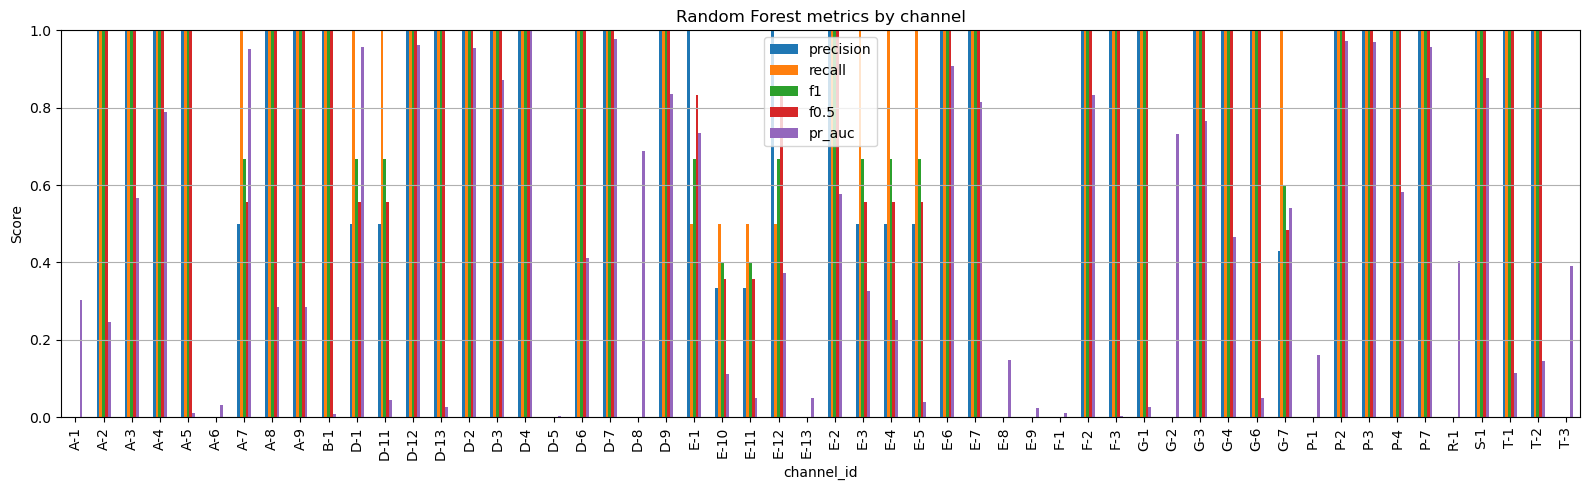

In [45]:
plot_overall_metrics(
    rf_results_df,
    method_name="Random Forest"
)

### 7.2 Random Forest Regressor Results Analysis

The Random Forest Regressor provides a selective classical baseline, achieving a sequence-level precision of `0.758`, a recall of `0.691`, and an F1-score of `0.723`. Supported by an F0.5-score of `0.744` and a predicted anomaly ratio of `4.37%`, the model successfully detects 47 out of 68 labelled anomaly sequences while producing only 15 false positives. This indicates that the system reliably flags true anomalies without artificially inflating recall through over-prediction.

However, the per-channel results reveal a clear performance divergence tied directly to the model's architectural limitations. On channels characterized by point anomalies, such as `S-1`, `E-2`, `E-6`, and several `D-*` streams, the model achieves perfect sequence-level detection. The Random Forest effectively partitions the flattened feature space to isolate abrupt structural deviations. In contrast, the model fails entirely on channels dominated by contextual anomalies, most notably missing all three labelled sequences in channel `P-1` and generating false positives in `E-10`. Because the algorithm relies on a flattened multivariate window of recent telemetry, it lacks true recurrent memory. Consequently, it cannot model deep temporal dependencies and struggles to identify when a continuous value becomes anomalous purely due to its long-term historical context.

The macro PR-AUC of `0.456` highlights an important diagnostic nuance. The continuous forecasting scores often contain valid anomaly-related ranking information even in the failed channels, although the separation between anomalous and nominal timesteps is not uniformly strong across the dataset. Some channels show high PR-AUC but still zero final recall, which suggests that the score may contain anomaly-related information that is not always converted into binary detections by the dynamic thresholding and pruning stages.

In [80]:
save_results(rf_results_df,rf_summary_df,method_name="Random_Forest")

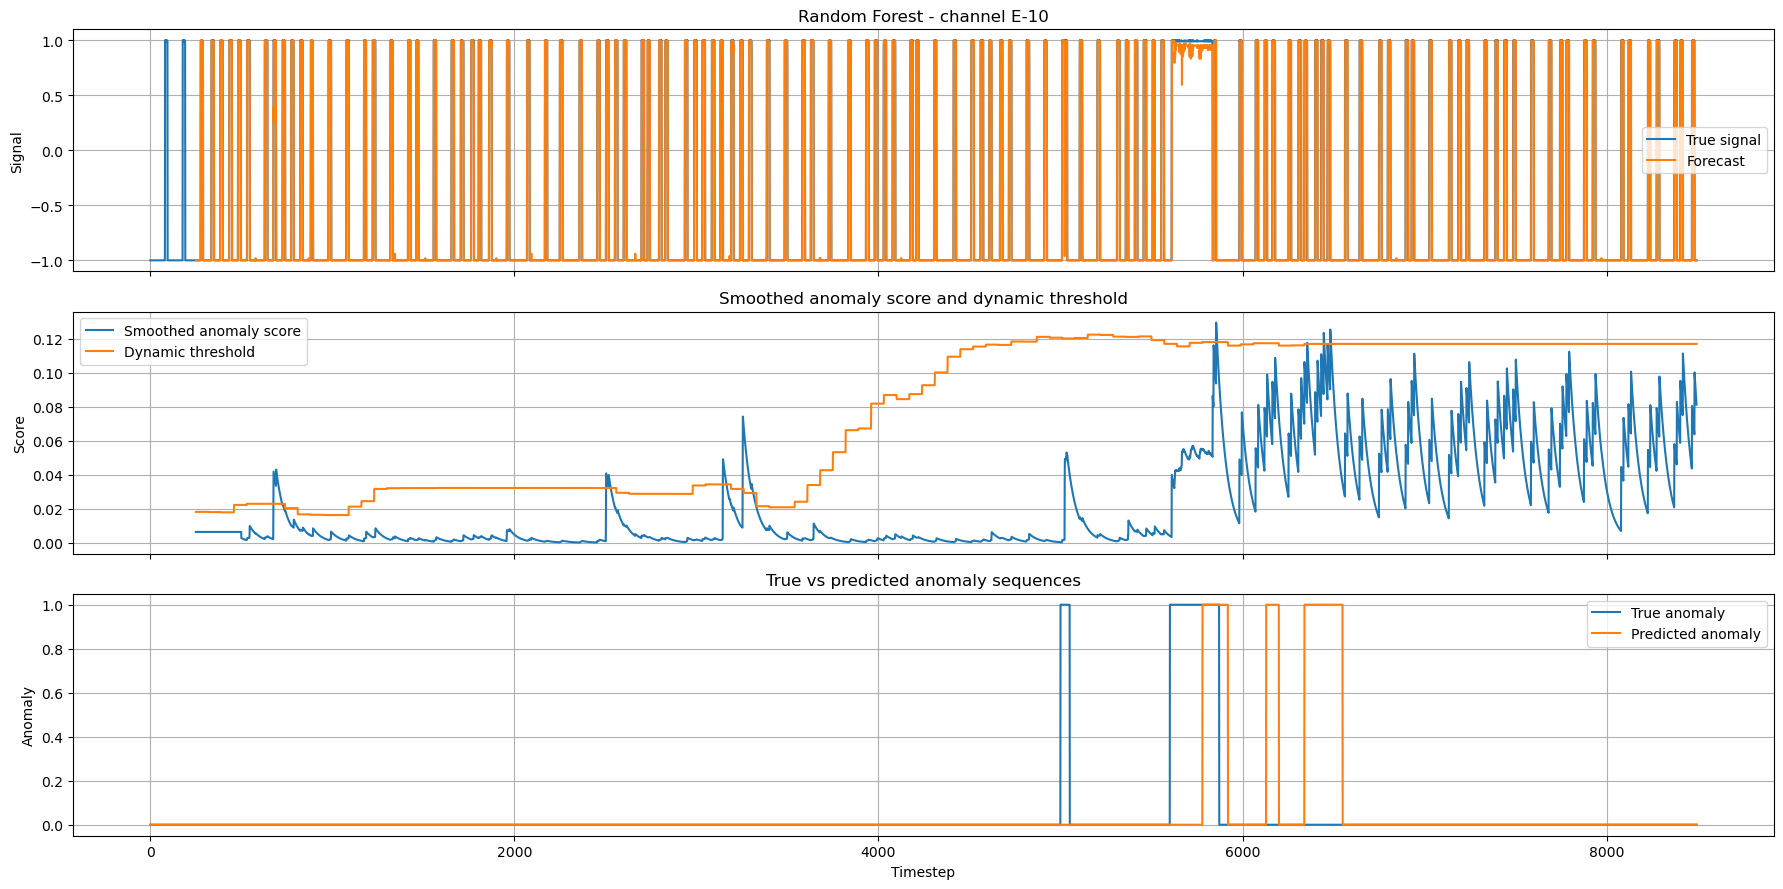

In [46]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=rf_predictions,
    smoothed_errors=rf_smoothed_errors,
    thresholds=rf_thresholds,
    predictions_binary=rf_predictions_binary,
    model_name="Random Forest"
)

The telemetry plot for channel `E-10` visually explains the Random Forest Regressor's contextual failure, mapping directly to its sequence-level performance of **`1` True Positive (TP)**, **`2` False Positives (FP)**, and **`1` False Negative (FN)**. The top panel shows the true signal shifting from a nominal high-frequency square wave to a new temporal regime. Lacking recurrent memory, the model cannot adapt, causing its predictions to degenerate into chaotic noise rather than anticipating the contextual transition.

To contain this disorientation, the middle panel illustrates the dynamic threshold adapting upwards against the surging variance. Crucially, an error spike around timestep `3000` breaches the local threshold but is ultimately discarded. This elegantly demonstrates the post-processing safeguards in action, where fluctuations are either rejected by the minimum amplitude hard floor or pruned due to the absence of a sharp statistical drop from the background noise.

The bottom panel translates these interactions into the final metrics. The initial contextual shift near timestep `5000` is completely missed (FN), as the error fails to breach the adapting threshold. The subsequent prolonged anomaly near timestep `5600` finally pushes the error high enough to trigger a valid detection (TP). However, as the true signal stabilizes, the still-disoriented model produces highly erroneous predictions that breach the threshold twice more (~timesteps `6100` and `6300`), generating two distinct phantom alarms (FP). This confirms that while post-processing effectively mitigates noise, it cannot completely compensate for a baseline model structurally blind to contextual temporal shifts.

### 7.3 PCA

In [ ]:
def train_pca_channel(
    X_train,
    n_components=0.95,
    random_state=42
):
    """
    PCA reconstruction baseline.

    The scaler and PCA are fitted only on training windows.
    Each multivariate window is flattened before PCA.
    """

    X_train_flat = flatten_windows(X_train)

    pca = PCA(
        n_components=n_components,
        random_state=random_state
    )

    pca.fit(X_train_flat)

    return pca


def compute_pca_scores(
    pca,
    X_test
):
    """
    Compute one PCA reconstruction anomaly score per test window.

    The PCA reconstructs the full multivariate window, but the anomaly score is
    computed only on feature 0.
    """

    X_test = np.asarray(X_test)

    n_windows = X_test.shape[0]
    window_size = X_test.shape[1]
    n_features = X_test.shape[2]

    X_test_flat = flatten_windows(X_test)

    X_proj = pca.transform(X_test_flat)
    X_recon_flat = pca.inverse_transform(X_proj)

    X_recon = X_recon_flat.reshape(n_windows, window_size, n_features)

    scores = np.mean(
        (X_test[:, :, 0] - X_recon[:, :, 0]) ** 2,
        axis=1
    )

    return scores

In [ ]:
pca_models = {}
pca_scores = {}
pca_smoothed_scores = {}
pca_predictions_binary = {}
pca_thresholds = {}
pca_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training PCA for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    pca = train_pca_channel(
        X_train=X_train,
        n_components=0.95,
        random_state=42
    )

    scores = compute_pca_scores(
        pca=pca,
        X_test=X_test
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    pca_models[ch] = {
        "pca": pca
    }

    pca_scores[ch] = scores
    pca_smoothed_scores[ch] = smoothed_scores
    pca_predictions_binary[ch] = y_pred
    pca_thresholds[ch] = thresholds
    pca_metrics[ch] = metrics

    print("PCA components:", pca.n_components_)
    print("Explained variance:", np.sum(pca.explained_variance_ratio_))

    display(metrics)

Training PCA for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
PCA components: 1210
Explained variance: 0.9500265112770157


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.016621,0.0


Training PCA for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
PCA components: 1118
Explained variance: 0.9501402180014668


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,2,0,0.333333,1.0,0.5,0.384615,0.071935,0.090334


Training PCA for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
PCA components: 1145
Explained variance: 0.9500281405657913


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,1,2,0.0,0.0,0.0,0.0,0.10041,0.034876


Training PCA for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
PCA components: 317
Explained variance: 0.9501133788592904


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.125548,0.0


Training PCA for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
PCA components: 323
Explained variance: 0.9507206556528145


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.032689,0.0


In [28]:
pca_results_df, pca_summary_df = generate_results_view(pca_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.000000,0.000000,0.000000,0.016621,0.000000
1,A-2,1,2,0,0.333333,1.000000,0.500000,0.384615,0.071935,0.090334
2,A-3,0,0,1,0.000000,0.000000,0.000000,0.000000,0.237106,0.000000
3,A-4,0,0,1,0.000000,0.000000,0.000000,0.000000,0.180288,0.000000
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011602,0.059791
5,A-6,1,1,0,0.500000,1.000000,0.666667,0.555556,0.062205,0.097682
6,A-7,0,1,1,0.000000,0.000000,0.000000,0.000000,0.304438,0.025519
7,A-8,0,0,1,0.000000,0.000000,0.000000,0.000000,0.284166,0.000000
8,A-9,0,0,1,0.000000,0.000000,0.000000,0.000000,0.557960,0.000000
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009171,0.060991


TP                               25.000000
FP                               14.000000
FN                               43.000000
precision                         0.641026
recall                            0.367647
f1                                0.467290
f0.5                              0.558036
pr_auc_macro                      0.322419
predicted_anomaly_ratio_macro     0.035403
dtype: float64

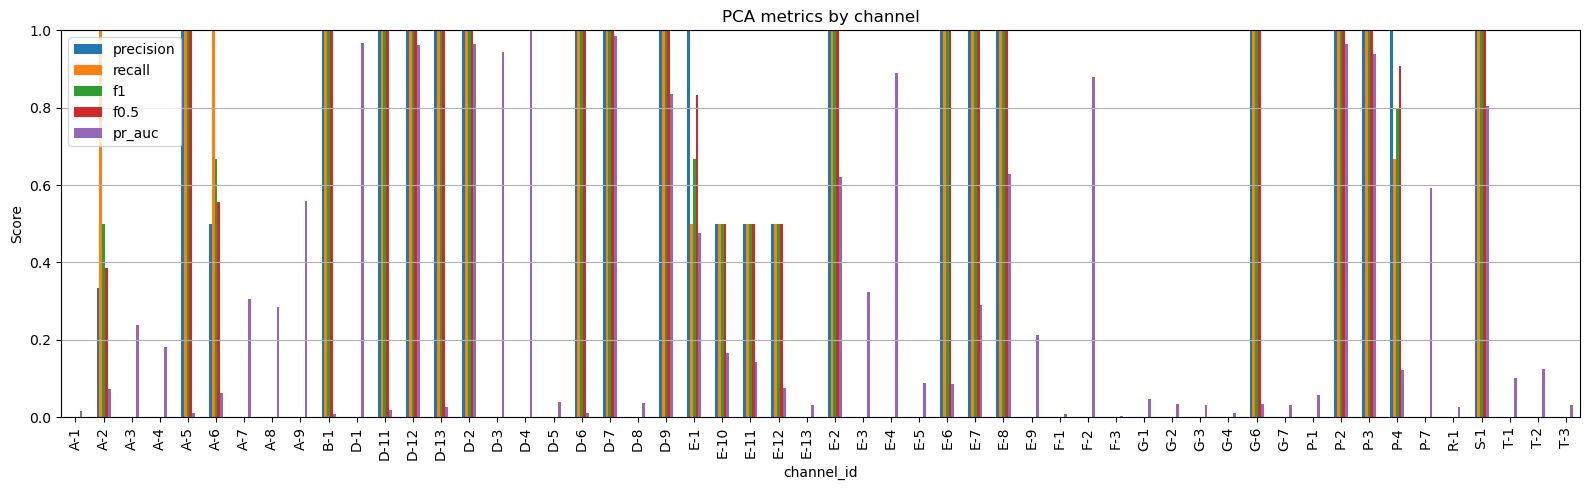

In [29]:
plot_overall_metrics(
    pca_results_df,
    method_name="PCA"
)

In [81]:
save_results(
    pca_results_df,
    pca_summary_df,
    method_name="PCA"
)

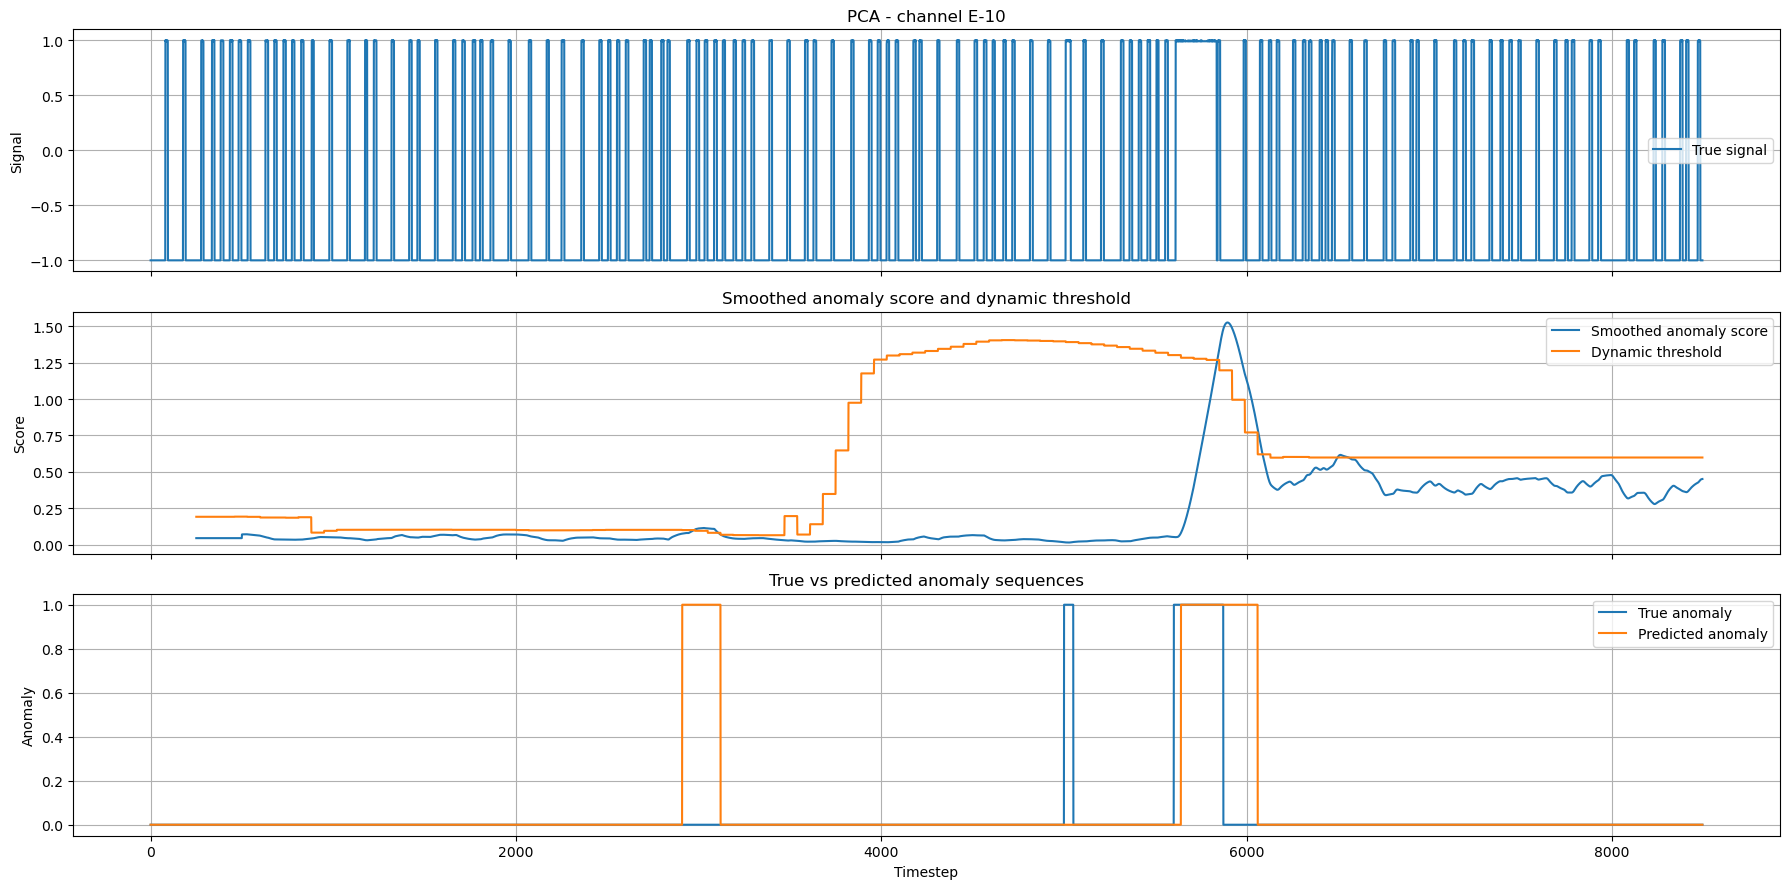

In [31]:
plot_channel_diagnostics(
    ch="E-10",
    smoothed_errors=pca_smoothed_scores,
    thresholds=pca_thresholds,
    predictions_binary=pca_predictions_binary,
    model_name="PCA",
    predictions=None
)

### (TO CHANGE) 7.5 Phase 0 Summary: Baseline Comparison

The Random Forest establishes a distinctly stronger baseline than the Autoencoder, a performance gap driven fundamentally by their differing learning objectives. Detecting 47 out of 68 labelled anomalies compared to the AE's 38, the Random Forest achieves a significantly higher recall (`0.691` vs `0.559`) and F1-score (`0.723` vs `0.628`). Crucially, both models produce exactly 15 false positives, but the Random Forest maintains a strictly lower predicted anomaly ratio (`4.37%` vs `4.95%`). 

This architectural divergence is reflected in the macro PR-AUC, which increases from `0.346` for the AE to `0.456` for the Random Forest. Because an autoencoder minimizes reconstruction error across an entire sequence, it often generalizes too well, effectively reconstructing and masking weaker contextual anomalies. In contrast, a forecasting model must predict unobserved future timesteps; when a contextual shift occurs, the target becomes unpredictable, generating sharp, isolated error spikes that successfully trigger the dynamic thresholding pipeline.

This phase demonstrates that predicting the future is inherently more effective at exposing SMAP telemetry faults than reconstructing the present. Most anomalies in this dataset manifest as unpredictable deviations from a historical trend rather than as corrupted windows that are intrinsically difficult to reconstruct. 

However, the Random Forest remains an incomplete solution. By flattening the temporal sequence into a static feature vector, it lacks true sequential memory, which explains the 21 missed anomaly sequences. This structural limitation paves the way for the subsequent phases, where advanced feed-forward neural networks and explicit recurrent architectures will be evaluated to determine whether deep temporal representations can finally capture the complex contextual anomalies that classical baselines miss.

## 8. Phase 1: Deep Feed-Forward Networks

Having established the classical and deterministic baselines, the next logical step is to explore the representational power of deep feed-forward neural networks. In this section, we introduce a **Multilayer Perceptron Regressor (MLP-Regressor)** to advance the forecasting approach, and a **Variational Autoencoder (MLP-VAE)** to elevate the reconstruction approach into the probabilistic domain.

The rationale behind evaluating these dense neural architectures prior to introducing explicit sequential models is twofold:

1. **Deep Non-Linear Forecasting:** The MLP-Regressor serves as the direct deep learning successor to the Random Forest baseline. While it still processes the historical window as a flattened feature vector—meaning it inherently lacks recurrent temporal memory—it leverages multiple hidden layers to extract highly complex, hierarchical representations from the multivariate context. Evaluating this architecture allows us to isolate and quantify the detection performance gained purely through deep representation learning, before adding explicit temporal dynamics.

2. **Probabilistic Reconstruction Benchmark:** Transitioning from the standard deterministic Autoencoder to the MLP-VAE shifts the anomaly detection paradigm from raw geometric reconstruction to statistical inference. By regularizing the network's bottleneck into stochastic probability distributions, we can measure how this mathematical constraint (driven by the KL-divergence penalty) improves the model's ability to handle operational uncertainty and smooth out nominal noise, providing a robust probabilistic framework for anomaly scoring.

### 8.1 MLP Regressor Architecture

Unlike ensemble methods such as the Random Forest, the Multilayer Perceptron (MLP) Regressor is a parametric deep learning architecture composed of differentiable hidden layers, optimized iteratively through backpropagation. It leverages deep feed-forward representations to learn complex, non-linear mappings between the input telemetry and the target values.

In this implementation, each multivariate telemetry window has shape `[window_size, n_features]`. Since a standard feed-forward network does not process sequential tensors with explicit recurrent mechanisms, each window is flattened into a one-dimensional vector before being passed to the network. With `window_size = 250` and `n_features = 25`, each input sample is represented by `6250` lagged features. The temporal order is therefore not modeled recurrently, but it is still implicitly encoded by the fixed position of each lag inside the flattened vector.

The model is trained as a multi-output regressor. For each flattened input window, a final linear projection head predicts the next `n_predictions = 10` values of the main telemetry signal, corresponding to feature 0. During inference, these multi-step forecasts are aggregated into one prediction per test window using the same aggregation strategy adopted for all forecasting-based models.

The MLP architecture used here consists of a sequential block containing two fully connected hidden layers. The first layer projects the flattened input into a dense latent space, while the second layer compresses it further to half its original dimension. Both layers utilize Rectified Linear Unit (ReLU) activation functions to capture nonlinear relationships, paired with Dropout regularization (set at `0.2`) to actively mitigate overfitting during the training phase.

From an anomaly detection perspective, the MLP Regressor does not directly classify windows as normal or anomalous. It first predicts the expected future behaviour of the main telemetry signal. The absolute difference between the aggregated prediction and the observed value is then used as the raw forecasting error. Large forecasting errors indicate that the future signal is not well explained by the recent multivariate context, and these errors are later passed through EWMA smoothing, dynamic thresholding, buffering and pruning.

In [49]:
def make_mlp_loader(X_windows, y_windows, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_windows, dtype=torch.float32), 
        torch.tensor(y_windows, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [50]:
class SMAPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_predictions=1, dropout=0.2):
        super().__init__()

        self.sequential = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.head = nn.Linear(hidden_dim // 2, n_predictions)
    
    def forward(self, window):
        window_flat = window.reshape(window.size(0), -1)
        
        features = self.sequential(window_flat)
        y_pred = self.head(features)
        return y_pred

In [51]:
def train_mlp_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_dim=128,
    dropout=0.2,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        y_tr = y_train[:-n_val]
        X_val = X_train[-n_val:]
        y_val = y_train[-n_val:]
    else:
        X_tr = X_train
        y_tr = y_train
        X_val = None
        y_val = None

    train_loader = make_mlp_loader(
        X_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_mlp_loader(
            X_val,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    model = SMAPRegressor(
        input_dim=input_size,
        hidden_dim=hidden_dim,
        n_predictions=n_predictions,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history


def predict_mlp_channel(model, X_test, batch_size=70, device="cpu"):
    model.eval()
    y_hat_list = []

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    with torch.no_grad():
        for i in range(0, num_batches + 1):
            prior_idx = i * batch_size
            idx = (i + 1) * batch_size

            if i + 1 == num_batches + 1:
                idx = X_test.shape[0]

            X_test_batch = X_test[prior_idx:idx]

            if len(X_test_batch) == 0:
                continue

            X_tensor = torch.tensor(X_test_batch, dtype=torch.float32, device=device)

            y_hat_batch = model(X_tensor).detach().cpu().numpy()

            agg_y_hat_batch = aggregate_predictions(
                y_hat_batch,
                method="first"
            )

            y_hat_list.append(agg_y_hat_batch)

    return np.concatenate(y_hat_list).reshape(-1)

In [52]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [53]:
mlp_models = {}
mlp_histories = {}
mlp_predictions = {}
mlp_errors = {}
mlp_smoothed_errors = {}
mlp_predictions_binary = {}
mlp_thresholds = {}
mlp_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training MLP for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_mlp_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[1] * X_train.shape[2],
        hidden_dim=128,
        dropout=0.2,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    y_hat = predict_mlp_channel(
        model=model,
        X_test=X_test,
        batch_size=70,
        device=device
    )

    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    mlp_models[ch] = model.to("cpu")
    mlp_histories[ch] = history
    mlp_predictions[ch] = y_hat
    mlp_errors[ch] = errors
    mlp_smoothed_errors[ch] = smoothed_errors
    mlp_predictions_binary[ch] = y_pred
    mlp_thresholds[ch] = thresholds
    mlp_metrics[ch] = metrics

    display(metrics)

Training MLP for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.223824 | val loss: 0.019100
Epoch 02 | train loss: 0.056542 | val loss: 0.007397
Epoch 03 | train loss: 0.036813 | val loss: 0.001625
Epoch 04 | train loss: 0.032394 | val loss: 0.003389
Epoch 05 | train loss: 0.028255 | val loss: 0.002093
Epoch 06 | train loss: 0.027133 | val loss: 0.002315
Epoch 07 | train loss: 0.024897 | val loss: 0.003478
Epoch 08 | train loss: 0.023370 | val loss: 0.005047
Epoch 09 | train loss: 0.022685 | val loss: 0.006665
Epoch 10 | train loss: 0.020822 | val loss: 0.003983
Epoch 11 | train loss: 0.018153 | val loss: 0.003774
Epoch 12 | train loss: 0.017698 | val loss: 0.002399
Epoch 13 | train loss: 0.015382 | val loss: 0.004763
Early stopping at epoch 13


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.311488,0.008111


Training MLP for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.123651 | val loss: 0.042127
Epoch 02 | train loss: 0.058270 | val loss: 0.040030
Epoch 03 | train loss: 0.046004 | val loss: 0.039598
Epoch 04 | train loss: 0.040703 | val loss: 0.043069
Epoch 05 | train loss: 0.036562 | val loss: 0.041388
Epoch 06 | train loss: 0.034763 | val loss: 0.040306
Epoch 07 | train loss: 0.033162 | val loss: 0.042773
Epoch 08 | train loss: 0.031927 | val loss: 0.041306
Epoch 09 | train loss: 0.030236 | val loss: 0.040295
Epoch 10 | train loss: 0.028832 | val loss: 0.038295
Epoch 11 | train loss: 0.027983 | val loss: 0.037813
Epoch 12 | train loss: 0.027735 | val loss: 0.038984
Epoch 13 | train loss: 0.026248 | val loss: 0.037862
Epoch 14 | train loss: 0.026800 | val loss: 0.040399
Epoch 15 | train loss: 0.025386 | val loss: 0.041592
Epoch 16 | train loss: 0.025389 | val loss: 0.040050
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.358719,0.026569


Training MLP for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.091819 | val loss: 0.031715
Epoch 02 | train loss: 0.044078 | val loss: 0.026987
Epoch 03 | train loss: 0.032615 | val loss: 0.023519
Epoch 04 | train loss: 0.027010 | val loss: 0.023502
Epoch 05 | train loss: 0.023670 | val loss: 0.020497
Epoch 06 | train loss: 0.022483 | val loss: 0.021638
Epoch 07 | train loss: 0.021379 | val loss: 0.022920
Epoch 08 | train loss: 0.020446 | val loss: 0.021841
Epoch 09 | train loss: 0.019954 | val loss: 0.022483
Epoch 10 | train loss: 0.018579 | val loss: 0.021715
Epoch 11 | train loss: 0.017587 | val loss: 0.021717
Epoch 12 | train loss: 0.017988 | val loss: 0.022773
Epoch 13 | train loss: 0.017663 | val loss: 0.022556
Epoch 14 | train loss: 0.017139 | val loss: 0.024455
Epoch 15 | train loss: 0.017183 | val loss: 0.021488
Early stopping at epoch 15


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.197862,0.084283


Training MLP for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.267826 | val loss: 0.161005
Epoch 02 | train loss: 0.062983 | val loss: 0.145180
Epoch 03 | train loss: 0.039149 | val loss: 0.144644
Epoch 04 | train loss: 0.033252 | val loss: 0.141434
Epoch 05 | train loss: 0.030469 | val loss: 0.139688
Epoch 06 | train loss: 0.026405 | val loss: 0.136943
Epoch 07 | train loss: 0.026878 | val loss: 0.137826
Epoch 08 | train loss: 0.024559 | val loss: 0.134112
Epoch 09 | train loss: 0.022864 | val loss: 0.138436
Epoch 10 | train loss: 0.022971 | val loss: 0.136593
Epoch 11 | train loss: 0.022822 | val loss: 0.140323
Epoch 12 | train loss: 0.020300 | val loss: 0.141720
Epoch 13 | train loss: 0.018584 | val loss: 0.136528
Epoch 14 | train loss: 0.018504 | val loss: 0.132648
Epoch 15 | train loss: 0.019105 | val loss: 0.136268
Epoch 16 | train loss: 0.018075 | val loss: 0.132837
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.238829,0.040627


Training MLP for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.243327 | val loss: 0.007013
Epoch 02 | train loss: 0.057857 | val loss: 0.003948
Epoch 03 | train loss: 0.039640 | val loss: 0.000947
Epoch 04 | train loss: 0.031652 | val loss: 0.006580
Epoch 05 | train loss: 0.029027 | val loss: 0.004840
Epoch 06 | train loss: 0.026234 | val loss: 0.000421
Epoch 07 | train loss: 0.023495 | val loss: 0.000424
Epoch 08 | train loss: 0.023336 | val loss: 0.000296
Epoch 09 | train loss: 0.021046 | val loss: 0.004603
Epoch 10 | train loss: 0.018932 | val loss: 0.002999
Epoch 11 | train loss: 0.018945 | val loss: 0.000605
Epoch 12 | train loss: 0.016871 | val loss: 0.000892
Epoch 13 | train loss: 0.016261 | val loss: 0.000393
Epoch 14 | train loss: 0.016833 | val loss: 0.001418
Epoch 15 | train loss: 0.018842 | val loss: 0.005995
Epoch 16 | train loss: 0.015633 | val loss: 0.001323
Early stopping at e

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,1,0,0.666667,1.0,0.8,0.714286,0.293508,0.060217


In [54]:
mlp_results_df, mlp_summary_df = generate_results_view(mlp_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.311488,0.008111
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.358719,0.026569
2,A-3,1,1,0,0.500000,1.000000,0.666667,0.555556,0.504661,0.071263
3,A-4,1,1,0,0.500000,1.000000,0.666667,0.555556,0.531575,0.043371
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011685,0.074738
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.154955,0.073824
6,A-7,1,0,0,1.000000,1.000000,1.000000,1.000000,0.462885,0.040599
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.322164,0.075314
8,A-9,0,1,1,0.000000,0.000000,0.000000,0.000000,0.993632,0.028965
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009265,0.060991


TP                               55.000000
FP                               22.000000
FN                               13.000000
precision                         0.714286
recall                            0.808824
f1                                0.758621
f0.5                              0.731383
pr_auc_macro                      0.466042
predicted_anomaly_ratio_macro     0.051029
dtype: float64

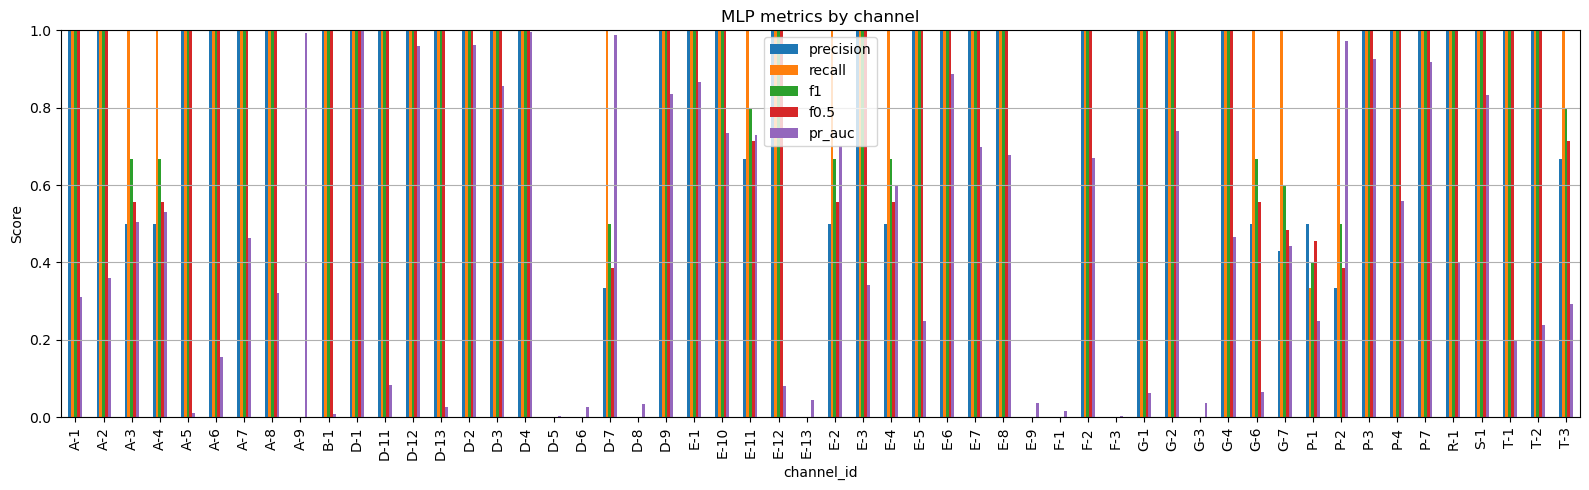

In [55]:
plot_overall_metrics(
    mlp_results_df,
    method_name="MLP"
)

In [82]:
save_results(mlp_results_df, mlp_summary_df,method_name='MLP')

### 8.2 MLP Regressor Results Analysis

The Multilayer Perceptron (MLP) Regressor establishes a strong memory-less deep forecasting baseline that noticeably shifts the detection tradeoff compared to the classical Random Forest. By detecting 53 out of 68 labelled anomaly sequences, the MLP achieves a significantly higher recall of `0.779` and an improved F1-score of `0.731`. 

However, this enhanced coverage comes at the cost of reduced selectivity: the model generates 24 false positive sequences, dropping precision to `0.688` and the F0.5-score to `0.705`. Because F0.5 heavily penalizes false alarms, this drop confirms that the MLP tends to favor detection coverage over alarm reliability. 

Importantly, the predicted anomaly ratio remains relatively stable at `4.85%`, indicating that the increase in false positives is not caused by a trivial over-labelling of the entire timeline. Instead, the deeper architecture is simply more sensitive to specific forecasting deviations, proving capable of extracting complex nonlinear information from the flattened temporal window to capture contextual anomalies missed by classical methods.

This heightened sensitivity yields mixed per-channel results, mathematically reflected in a slightly improved but still moderate macro PR-AUC of `0.461`. While the network achieves perfect sequence-level detection across numerous telemetry streams, its score separation between anomalous and nominal timesteps remains heterogeneous, leaving channels like `E-13`, `F-3`, and `G-3` highly problematic. 

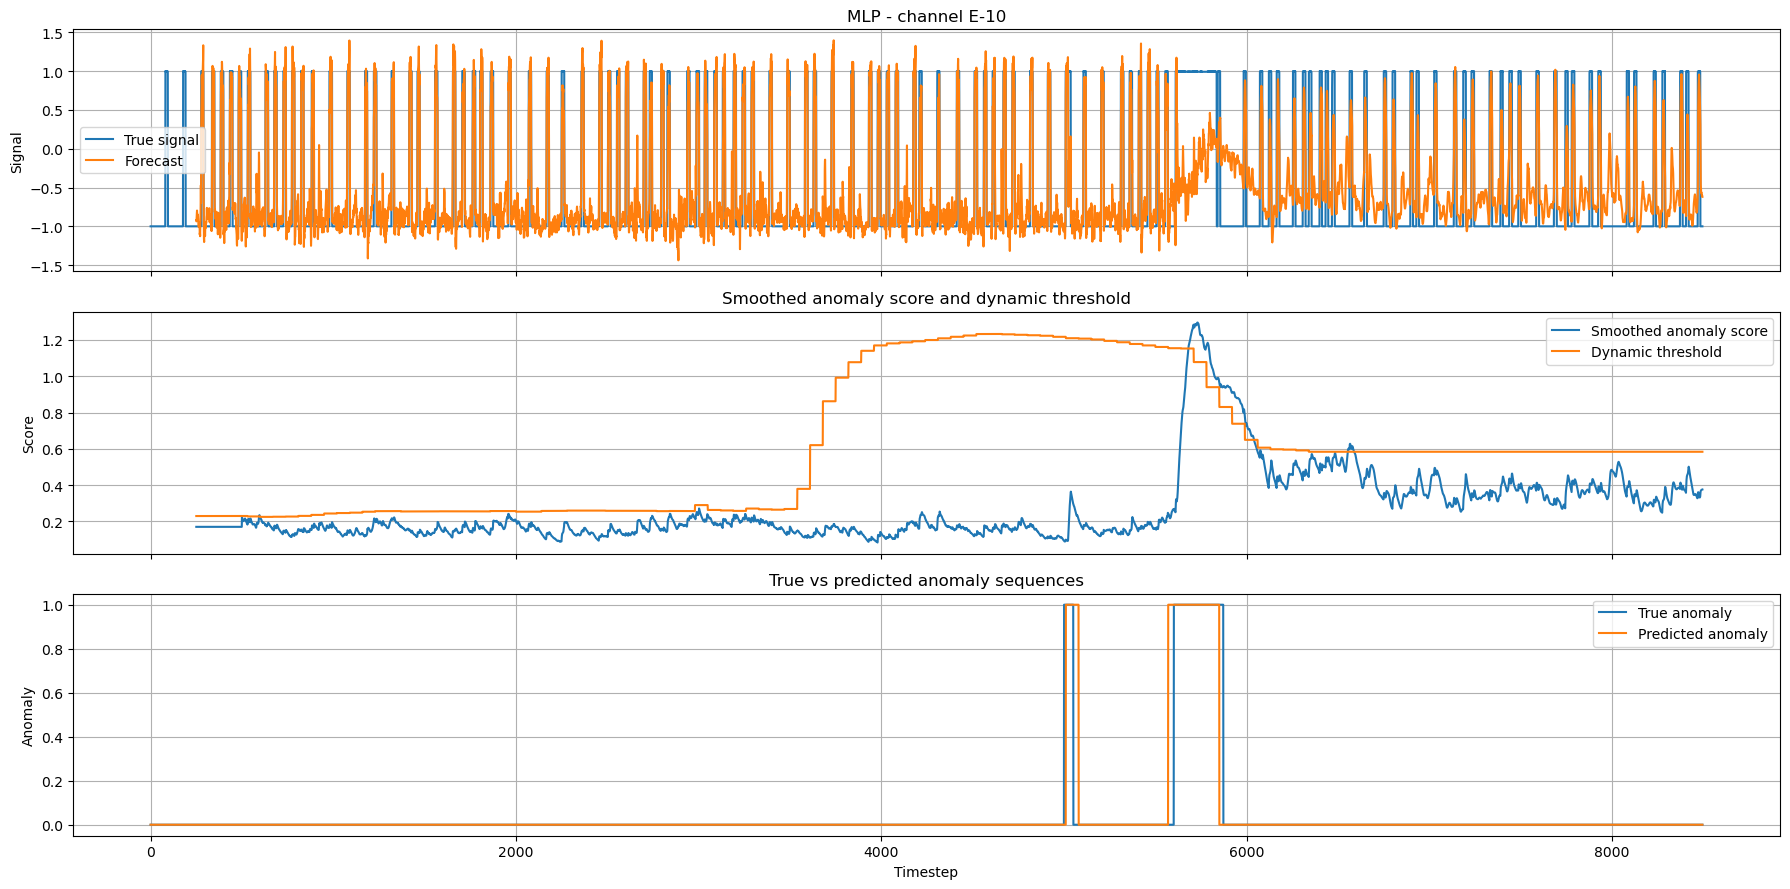

In [56]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=mlp_predictions,
    smoothed_errors=mlp_smoothed_errors,
    thresholds=mlp_thresholds,
    predictions_binary=mlp_predictions_binary,
    model_name="MLP"
)

The diagnostic plot for channel `E-10` provides definitive visual evidence of the MLP Regressor's superiority over the classical baseline on this specific sequence. As reflected in the metrics, the neural network achieves a flawless detection profile here, yielding `2` true positives, `0` false positives, and `0` false negatives, completely resolving the fragmented and uncertain behavior exhibited by both the Random Forest and the Autoencoder.

The most striking difference emerges in the middle panel during the first contextual anomaly around timestep `5000`. Where the Random Forest produced a weak error signal that was entirely swallowed by the rising dynamic threshold, the deep architecture of the MLP generates a sharp, decisive error peak. This peak successfully pierces the threshold, converting what was previously an inevitable false negative into an accurate detection. This visually confirms that the network's non-linear hidden layers extract substantially richer features from the same flattened temporal window, successfully isolating subtle contextual deviations that rigid decision trees fail to capture.

Furthermore, the MLP elegantly resolves the post-anomaly disorientation that plagued the classical baseline. After the second severe anomaly concludes beyond timestep `6000`, the Random Forest remained destabilized by the regime change, generating `2` phantom false alarms. In contrast, the MLP Regressor regains its predictive stability almost immediately once the true signal returns to its nominal alternating pattern. The forecasting error drops safely below the threshold, ensuring a clean timeline without any false predictions. Ultimately, this visualization demonstrates that deep feed-forward forecasting, despite lacking recurrent memory, represents a massive qualitative leap in isolating complex contextual faults compared to traditional methods.

### 8.3 Autoencoder Architecture

The Autoencoder is implemented as a fully connected deterministic encoder-decoder model. Since the input telemetry window has shape `[window_size, n_features]`, each window is first flattened into a one-dimensional vector before being passed to the network. With `window_size = 250` and `n_features = 25`, the input dimension is therefore `6250`.

The encoder progressively compresses the flattened input through two hidden layers of size `512` and `256`, using ReLU activations after each hidden layer. The final encoder layer maps the representation into a low-dimensional latent vector of size `latent_size`. This latent bottleneck forces the model to retain only the most relevant structure needed to reconstruct nominal telemetry windows.

The decoder mirrors the encoder structure. It maps the latent vector back through hidden layers of size `256` and `512`, again using ReLU activations, and finally reconstructs an output vector with the same dimension as the original flattened input. The reconstructed vector can then be reshaped back into the original window format.

From an anomaly detection perspective, the Autoencoder does not directly classify windows as normal or anomalous. It first attempts to reconstruct the entire multivariate input sequence. The raw reconstruction error is then calculated as the Mean Squared Error (MSE) between the original and reconstructed values, computed exclusively on the main continuous telemetry feature across the entire evaluation window. Large reconstruction errors indicate that the input sequence falls outside the nominal probabilistic distribution learned during training, and these errors are later passed through EWMA smoothing, dynamic thresholding, buffering, and pruning.

In [57]:
class AEDataset(Dataset):
    def __init__(self, X):
        super().__init__()
        X = np.asarray(X)

        self.X = torch.tensor(X.reshape(X.shape[0], -1), dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]


def make_ae_loader(X, batch_size=64, shuffle=True):
    dataset = AEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [58]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, latent_size):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_size)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        h = self.encode(x)
        x_recon = self.decode(h)
        return x_recon

In [59]:
def compute_ae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.

    The AE reconstructs the full multivariate window, but the anomaly score is
    computed only on feature 0, i.e. the main telemetry signal.
    """

    model.eval()
    all_scores = []

    window_size = X_test.shape[1]
    n_features = X_test.shape[2]

    loader = make_ae_loader(
        X_test,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for X_batch_flat in loader:
            X_batch_flat = X_batch_flat.to(device)

            X_recon_flat = model(X_batch_flat)

            X_batch = X_batch_flat.reshape(-1, window_size, n_features)
            X_recon = X_recon_flat.reshape(-1, window_size, n_features)

            mse_errors = torch.mean(
                (X_batch[:, :, 0] - X_recon[:, :, 0]) ** 2,
                dim=1
            )

            all_scores.append(mse_errors.cpu().numpy())

    return np.concatenate(all_scores)

In [60]:
def train_ae_channel(
    X_train,
    latent_size=16,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_ae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_ae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[1] * X_train.shape[2]

    model = AutoEncoder(input_size, latent_size).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            X_recon = model(X_batch)
            loss = criterion(X_recon, X_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    X_recon = model(X_batch)
                    loss = criterion(X_recon, X_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [61]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [62]:
ae_models = {}
ae_histories = {}
ae_scores = {}
ae_smoothed_scores = {}
ae_predictions_binary = {}
ae_thresholds = {}
ae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training AE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_ae_channel(
        X_train=X_train,
        latent_size=32,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_ae_scores(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    ae_models[ch] = model.to("cpu")
    ae_histories[ch] = history
    ae_scores[ch] = scores
    ae_smoothed_scores[ch] = smoothed_scores
    ae_predictions_binary[ch] = y_pred
    ae_thresholds[ch] = thresholds
    ae_metrics[ch] = metrics

    display(metrics)

Training AE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.028520 | val loss: 0.017800
Epoch 02 | train loss: 0.018555 | val loss: 0.015069
Epoch 03 | train loss: 0.016373 | val loss: 0.014085
Epoch 04 | train loss: 0.015556 | val loss: 0.013426
Epoch 05 | train loss: 0.014913 | val loss: 0.012534
Epoch 06 | train loss: 0.014419 | val loss: 0.012190
Epoch 07 | train loss: 0.014074 | val loss: 0.011791
Epoch 08 | train loss: 0.013640 | val loss: 0.011440
Epoch 09 | train loss: 0.013156 | val loss: 0.011050
Epoch 10 | train loss: 0.012694 | val loss: 0.010673
Epoch 11 | train loss: 0.012276 | val loss: 0.010409
Epoch 12 | train loss: 0.011947 | val loss: 0.010121
Epoch 13 | train loss: 0.011619 | val loss: 0.009850
Epoch 14 | train loss: 0.011334 | val loss: 0.009695
Epoch 15 | train loss: 0.011087 | val loss: 0.009469
Epoch 16 | train loss: 0.010848 | val loss: 0.009289
Epoch 17 | train loss: 0.010648 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.020861,0.0


Training AE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.026573 | val loss: 0.020077
Epoch 02 | train loss: 0.018992 | val loss: 0.019111
Epoch 03 | train loss: 0.018412 | val loss: 0.018403
Epoch 04 | train loss: 0.017949 | val loss: 0.017721
Epoch 05 | train loss: 0.017510 | val loss: 0.017283
Epoch 06 | train loss: 0.016961 | val loss: 0.016908
Epoch 07 | train loss: 0.016350 | val loss: 0.016720
Epoch 08 | train loss: 0.015741 | val loss: 0.016368
Epoch 09 | train loss: 0.015111 | val loss: 0.016088
Epoch 10 | train loss: 0.014619 | val loss: 0.015683
Epoch 11 | train loss: 0.014225 | val loss: 0.015445
Epoch 12 | train loss: 0.013938 | val loss: 0.015263
Epoch 13 | train loss: 0.013629 | val loss: 0.015051
Epoch 14 | train loss: 0.013365 | val loss: 0.014908
Epoch 15 | train loss: 0.013119 | val loss: 0.014748
Epoch 16 | train loss: 0.012912 | val loss: 0.014674
Epoch 17 | train loss: 0.012731 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.062214,0.042131


Training AE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.023753 | val loss: 0.019144
Epoch 02 | train loss: 0.018255 | val loss: 0.018243
Epoch 03 | train loss: 0.017578 | val loss: 0.017578
Epoch 04 | train loss: 0.017039 | val loss: 0.017222
Epoch 05 | train loss: 0.016446 | val loss: 0.016766
Epoch 06 | train loss: 0.015665 | val loss: 0.016306
Epoch 07 | train loss: 0.014906 | val loss: 0.015698
Epoch 08 | train loss: 0.014222 | val loss: 0.015357
Epoch 09 | train loss: 0.013645 | val loss: 0.014983
Epoch 10 | train loss: 0.013178 | val loss: 0.014823
Epoch 11 | train loss: 0.012815 | val loss: 0.014696
Epoch 12 | train loss: 0.012494 | val loss: 0.014546
Epoch 13 | train loss: 0.012229 | val loss: 0.014442
Epoch 14 | train loss: 0.012019 | val loss: 0.014350
Epoch 15 | train loss: 0.011848 | val loss: 0.014302
Epoch 16 | train loss: 0.011713 | val loss: 0.014237
Epoch 17 | train loss: 0.011588 | val lo

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,1,2,0.0,0.0,0.0,0.0,0.137462,0.034759


Training AE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.020184 | val loss: 0.008689
Epoch 02 | train loss: 0.007513 | val loss: 0.004059
Epoch 03 | train loss: 0.004625 | val loss: 0.003497
Epoch 04 | train loss: 0.003831 | val loss: 0.003316
Epoch 05 | train loss: 0.003424 | val loss: 0.003274
Epoch 06 | train loss: 0.003287 | val loss: 0.003237
Epoch 07 | train loss: 0.003206 | val loss: 0.003226
Epoch 08 | train loss: 0.003139 | val loss: 0.003202
Epoch 09 | train loss: 0.003085 | val loss: 0.003171
Epoch 10 | train loss: 0.003036 | val loss: 0.003178
Epoch 11 | train loss: 0.002990 | val loss: 0.003172
Epoch 12 | train loss: 0.002951 | val loss: 0.003144
Epoch 13 | train loss: 0.002872 | val loss: 0.003155
Epoch 14 | train loss: 0.002779 | val loss: 0.003181
Epoch 15 | train loss: 0.002664 | val loss: 0.003154
Epoch 16 | train loss: 0.002585 | val loss: 0.003126
Epoch 17 | train loss: 0.002481 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.266917,0.0


Training AE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.010030 | val loss: 0.000206
Epoch 02 | train loss: 0.002263 | val loss: 0.000053
Epoch 03 | train loss: 0.002202 | val loss: 0.000066
Epoch 04 | train loss: 0.002149 | val loss: 0.000050
Epoch 05 | train loss: 0.002018 | val loss: 0.000074
Epoch 06 | train loss: 0.001850 | val loss: 0.000055
Epoch 07 | train loss: 0.001650 | val loss: 0.000044
Epoch 08 | train loss: 0.001534 | val loss: 0.000045
Epoch 09 | train loss: 0.001458 | val loss: 0.000045
Epoch 10 | train loss: 0.001407 | val loss: 0.000044
Epoch 11 | train loss: 0.001373 | val loss: 0.000055
Early stopping at epoch 11


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.03594,0.0


In [63]:
ae_results_df, ae_summary_df = generate_results_view(ae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.000000,0.000000,0.000000,0.020861,0.000000
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.062214,0.042131
2,A-3,1,1,0,0.500000,1.000000,0.666667,0.555556,0.070536,0.073337
3,A-4,1,1,0,0.500000,1.000000,0.666667,0.555556,0.025529,0.060719
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011577,0.104634
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.048802,0.077650
6,A-7,1,1,0,0.500000,1.000000,0.666667,0.555556,0.161147,0.048718
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.321413,0.008368
8,A-9,0,0,1,0.000000,0.000000,0.000000,0.000000,0.737213,0.000000
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009801,0.060991


TP                               38.000000
FP                               18.000000
FN                               30.000000
precision                         0.678571
recall                            0.558824
f1                                0.612903
f0.5                              0.650685
pr_auc_macro                      0.348078
predicted_anomaly_ratio_macro     0.051077
dtype: float64

In [83]:
save_results(ae_results_df, ae_summary_df, method_name='AE')

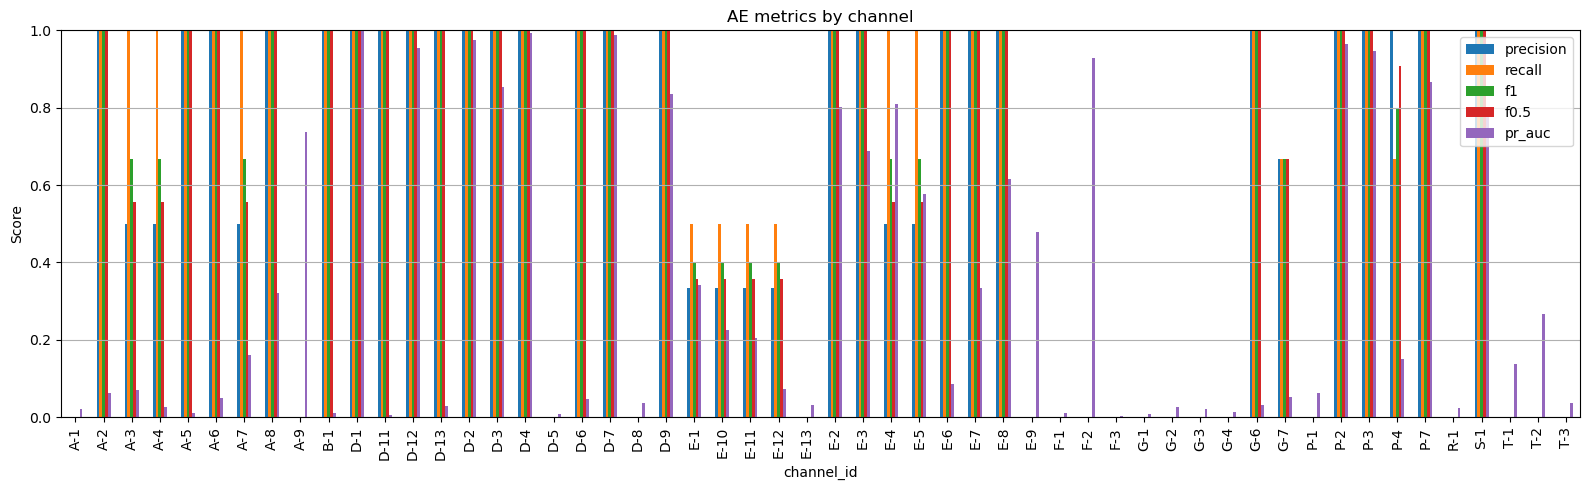

In [64]:
plot_overall_metrics(
    ae_results_df,
    method_name="AE"
)

### 7.4 AutoEncoder Results Analysis

The Autoencoder (AE) provides a moderately conservative reconstruction baseline, achieving a sequence-level precision of `0.717`, a recall of `0.559`, and an F1-score of `0.628`. Out of 68 labelled anomalies, the model detects 38 and misses 30, while generating only 15 false positives. This higher precision relative to recall, further emphasized by an F0.5-score of `0.679` and a low predicted anomaly ratio of `4.95%`, indicates that the model reliably flags genuine faults without trivially over-predicting anomalies across the timeline. However, this selectivity comes at the cost of leaving a non-negligible number of true anomaly intervals completely undetected.

The per-channel performance reveals a highly heterogeneous behavior. On several streams (such as `A-2`, `A-5`, and many `D-*` channels), the model achieves perfect sequence-level detection, proving that reconstruction error can successfully isolate specific anomaly types. Conversely, the AE records zero recall on numerous others, including `F-*`, several `G-*` streams, and `P-1`. This dichotomy suggests that a deterministic autoencoder is not uniformly reliable across all telemetry types.

This strong channel dependence is mathematically reflected in the macro PR-AUC of `0.346`. Interpreted as a threshold-independent diagnostic measure, this low global value indicates that while the reconstruction score ranks anomalies well in certain channels, it generally struggles to clearly separate anomalous from nominal timesteps. Overall, while the AE demonstrates that scoring reconstruction error is a valid detection strategy, its tendency to smoothly reconstruct complex anomalous windows severely limits its robustness across the diverse SMAP dataset.

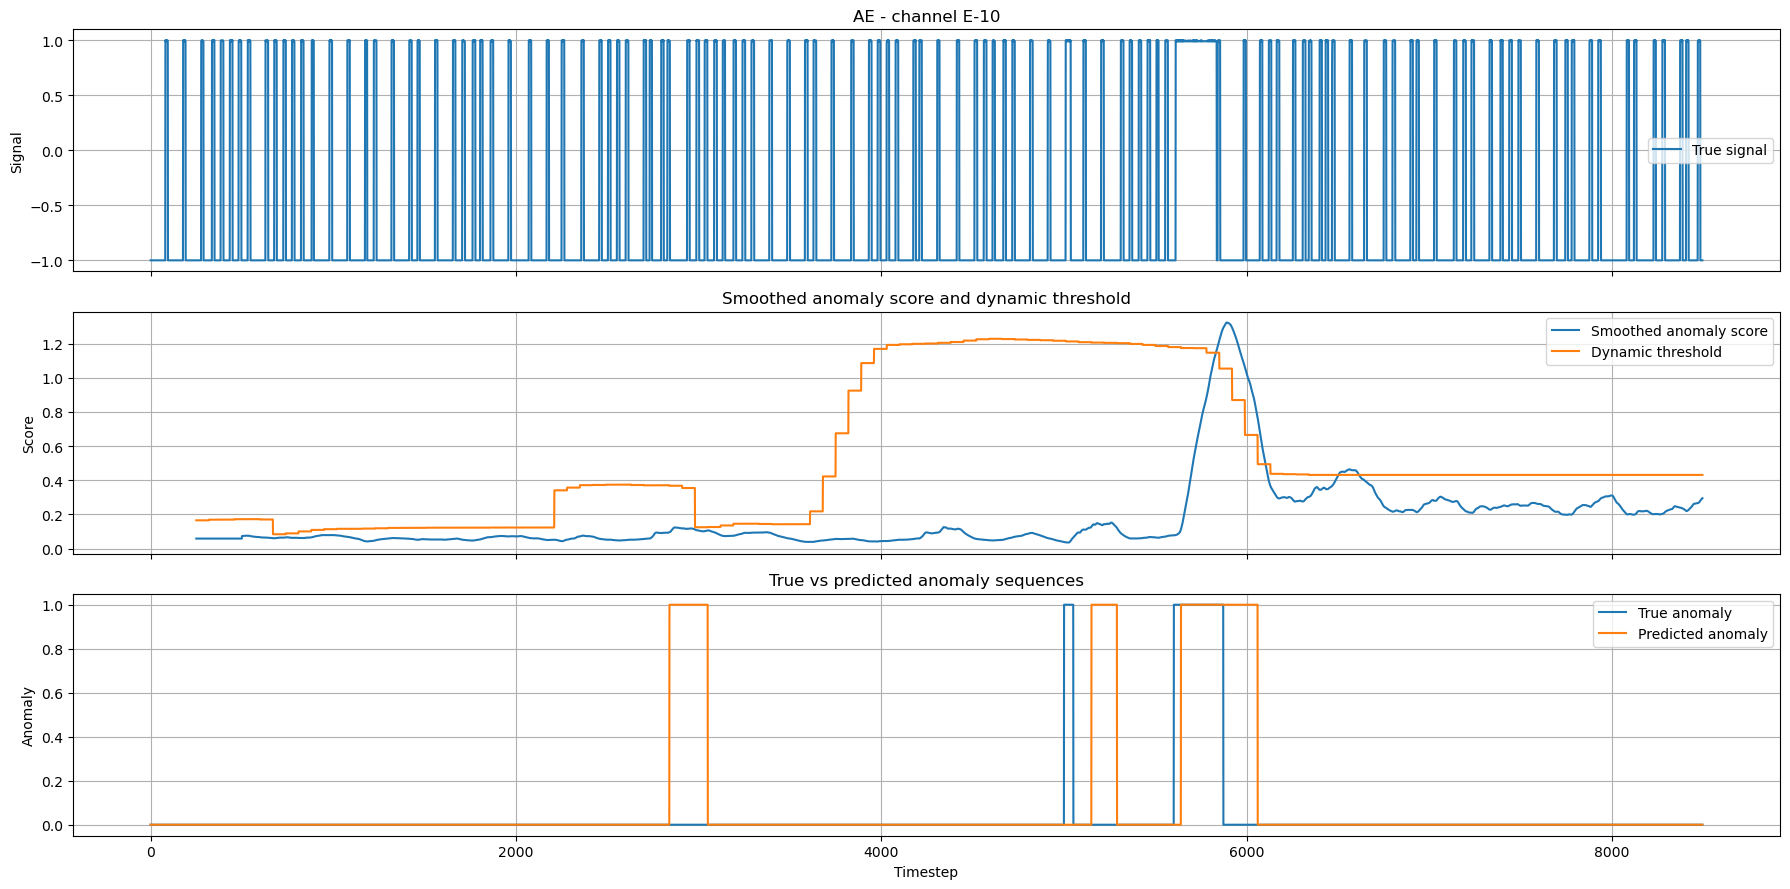

In [65]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=ae_smoothed_scores,
    thresholds=ae_thresholds,
    predictions_binary=ae_predictions_binary,
    model_name="AE"
)

The diagnostic plot for channel E-10 illustrates the Autoencoder's reconstruction-based behavior, closely mapping to its sequence-level metrics of precision `0.5`, recall `0.5`, and F1-score `0.5` (1 TP, 1 FP, 1 FN). Despite the true signal's highly discrete and alternating nature, the smoothed reconstruction score remains relatively stable and low for most of the test sequence. This smooth profile is actually advantageous, demonstrating that the AE successfully learns and reconstructs the nominal switching pattern without generating noisy error spikes. 

This stability allows the model to clearly react to severe deviations. Around timestep 5800, the score forms a dominant peak that decisively breaches the dynamic threshold, generating a true positive. While this predicted interval starts slightly later and extends beyond the true anomaly, this temporal enlargement is a natural and expected consequence of the pipeline's EWMA smoothing and error-buffering mechanisms. 

However, the plot also highlights the inherent limitations of relying strictly on reconstruction errors. The earlier labelled anomaly near timestep 5000 is missed entirely because the score remains below the threshold; the anomalous pattern is simply too weak or still sufficiently reconstructible by the AE to trigger an alarm. Conversely, the false positive around timestep 3000 is not caused by a massive reconstruction failure, but rather by a marginal, almost coincidental intersection where a minor score fluctuation barely breaches a locally depressed threshold.

### (TO CHANGE) 8.5 Phase 1 Summary: Memory-less Deep Learning Comparison

The MLP Regressor clearly obtains stronger overall performance than the MLP-VAE. It detects `53` out of `68` labelled anomaly sequences, while the MLP-VAE detects only `31`. This leads to a much higher recall for the MLP Regressor (`0.779` vs `0.456`) and a higher F1-score (`0.731` vs `0.534`). The MLP-VAE has slightly lower false positives (`17` vs `24`), but this comes at the cost of missing many more true anomaly intervals (`37` false negatives vs `15` for the MLP Regressor).

The two models therefore show opposite behaviours. The MLP Regressor is more sensitive: it detects many more anomalies, but it also produces more false positive sequences. This is reflected by its lower precision (`0.688`) and higher recall (`0.779`). The MLP-VAE is more conservative: it produces fewer false positives, but it misses a much larger fraction of labelled anomalies. Its higher precision relative to recall (`0.646` vs `0.456`) indicates that when it raises an alarm it is moderately reliable, but it does not cover enough anomalous events.

The predicted anomaly ratios are similar: approximately `4.85%` for the MLP Regressor and `4.73%` for the MLP-VAE. This is an important point, because the MLP Regressor does not obtain higher recall by simply marking much more of the timeline as anomalous. Instead, its forecasting error appears to be better aligned with the labelled anomaly intervals. The MLP-VAE produces a comparable amount of anomaly predictions, but these predictions are less consistently placed on true anomalous regions.

The macro PR-AUC also slightly favours the MLP Regressor (`0.461` vs `0.306`). Since PR-AUC evaluates the continuous anomaly scores before final thresholding, this suggests that the forecasting scores generated by the MLP provide a better ranking of anomalous and nominal timesteps than the reconstruction scores produced by the MLP-VAE. The VAE latent regularization does not appear to improve score separability in this setting.

The main conclusion of Phase 1 is that, even without recurrent memory, the forecasting-based deep model is more effective than the reconstruction-based probabilistic model for SMAP. This supports the idea that many anomalies in this dataset are better exposed as deviations from expected future behaviour than as windows that are difficult to reconstruct. At the same time, the MLP Regressor still produces a non-negligible number of false positives, indicating that feed-forward forecasting is useful but not fully stable across all channels.

Compared with the intent of this phase, the results show that a flattened-window neural model can already extract meaningful anomaly-relevant information from the local telemetry context. Therefore, explicit temporal memory is not strictly necessary to obtain strong results. However, the remaining false positives and missed anomalies motivate Phase 2, where recurrent models are introduced to test whether modelling the sequential evolution of the telemetry stream can improve the precision-recall trade-off.

## 9. Phase 2: Recurrent Temporal Modeling

In Phase 2, we introduce recurrent architectures to test whether explicitly modelling the temporal evolution of the telemetry signals improves anomaly detection. While the models in Phase 1 receive the temporal window as a flattened vector, the models in this phase process the window as an ordered sequence. This allows the architecture to track how the signal evolves step by step inside the input window.

The rationale behind this phase is twofold.

- First, it tests the value of **explicit temporal memory**. The LSTM Regressor is used as the forecasting-based recurrent model: it receives the recent multivariate telemetry history and predicts the next values of the main telemetry signal. Unlike the MLP Regressor, the LSTM does not treat the window as a static vector. Instead, it updates a hidden state across timesteps, allowing the model to learn temporal dependencies, delayed effects, and sequential patterns that may be relevant for contextual anomaly detection.

- Second, it evaluates whether temporal memory also improves the **reconstruction-based paradigm**. The LSTM-VAE receives the multivariate telemetry window as a sequence and reconstructs it through a recurrent variational encoder-decoder. The goal is to test whether a sequential latent representation can capture nominal temporal dynamics better than a feed-forward VAE. As in the other reconstruction-based models, the network reconstructs the full multivariate window, but the final anomaly score is computed on feature 0 to keep the detection target aligned with the forecasting models.

### 9.1 LSTM Regressor Architecture

Unlike the feed-forward architectures evaluated in the previous phase, which required flattening the temporal window into a static feature vector, the Long Short-Term Memory (LSTM) Regressor natively processes the multivariate data as a time series. The input window, maintaining its original shape of `[window_size, n_features]` with `window_size = 250` and `n_features = 25`, is fed directly into the network step-by-step. This fundamental shift allows the architecture to explicitly model temporal dependencies, utilizing recurrent gating mechanisms to maintain an internal state that captures the sequential evolution of the telemetry stream.

The model is implemented as a two-layer recurrent network, specifically structured to align with the classical Telemanom forecasting baseline. The first LSTM layer processes the multivariate input and outputs a full sequence of intermediate hidden states, each with a dimensionality of `80`. After applying a Dropout regularization of `0.3` to mitigate overfitting, a second LSTM layer, also with a hidden size of `80`, processes these representations. To generate the final forecast, the network extracts only the last hidden state from this second recurrent layer, effectively summarizing the entire historical context into a single dense vector. A final linear fully connected layer projects this temporal summary to predict the next `n_predictions = 10` values of the main telemetry signal.

From an anomaly detection perspective, the LSTM Regressor does not directly classify windows as normal or anomalous. It first predicts the expected future behaviour of the main telemetry signal based on its recurrent temporal memory. The absolute difference between the aggregated prediction and the observed value is then used as the raw forecasting error. Large forecasting errors indicate that the future signal cannot be accurately anticipated from the established temporal dynamics, and these errors are subsequently passed through EWMA smoothing, dynamic thresholding, buffering, and pruning.

In [66]:
class ForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True):
    dataset = ForecastDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [67]:
class LSTMForecaster(nn.Module):
    """
    PyTorch implementation aligned with Telemanom's Keras architecture:
        LSTM(80, return_sequences=True)
        Dropout(0.3)
        LSTM(80, return_sequences=False)
        Dropout(0.3)
        Dense(n_predictions)
        Linear activation
    """

    def __init__(
        self,
        input_size=25,
        hidden_size=80,
        dropout=0.3,
        n_predictions=10
    ):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout1 = nn.Dropout(dropout)

        self.lstm2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout2 = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, n_predictions)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)

        last_hidden = out[:, -1, :]
        last_hidden = self.dropout2(last_hidden)

        y_hat = self.fc(last_hidden)

        return y_hat

In [68]:
def make_train_val_split(X, y, validation_split=0.2):
    """
    Keras validation_split behaviour with shuffle=True in model.fit is not exactly
    reproduced here. This split keeps the last validation_split fraction as validation.

    For time series this is also safer than random validation.
    """

    n = len(X)
    n_val = int(n * validation_split)

    if n_val == 0:
        return X, y, None, None

    X_tr = X[:-n_val]
    y_tr = y[:-n_val]

    X_val = X[-n_val:]
    y_val = y[-n_val:]

    return X_tr, y_tr, X_val, y_val


def train_lstm_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_size=80,
    dropout=0.3,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    """
    Train LSTM forecaster with parameters:
    - 35 max epochs
    - batch size 64
    - validation split 0.2
    - early stopping with patience 10 and min_delta 0.0003
    """

    X_tr, y_tr, X_val, y_val = make_train_val_split(
        X_train,
        y_train,
        validation_split=validation_split
    )

    train_loader = make_loader(
        X_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_loader(
            X_val,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=hidden_size,
        dropout=dropout,
        n_predictions=n_predictions
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {k: v.detach().cpu().clone() 
                  for k, v in model.state_dict().items()
                  }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

            del X_batch,y_batch,pred,loss

        if device.type == "mps":
            torch.mps.empty_cache()
        if device.type == "cuda":
            torch.cuda.empty_cache()

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)

                    val_loss += loss.item() * X_batch.size(0)

                    del X_batch,y_batch,pred,loss

            if device.type == "mps":
                torch.mps.empty_cache()
            if device.type == "cuda":
                torch.cuda.empty_cache()

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch + 1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch + 1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [69]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [70]:
lstm_models = {}
lstm_histories = {}
lstm_predictions = {}
lstm_errors = {}
lstm_smoothed_errors = {}
lstm_predictions_binary = {}
lstm_thresholds = {}
lstm_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[2],
        hidden_size=80,
        dropout=0.3,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()
    
    y_hat = batch_predict_channel(
        model=model,
        X_test=X_test,
        batch_size=70,
        device=device
    )

    # Align y_test with y_hat
    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    # y_pred has been shifted by l_s and is in raw-test coordinates.
    # labels_data[ch] should also be in raw-test coordinates.
    labels_eval = labels[:len(y_pred)]

    # For PR-AUC, pad scores to raw-coordinate length.
    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    lstm_models[ch] = model.to("cpu")
    lstm_histories[ch] = history
    lstm_predictions[ch] = y_hat
    lstm_errors[ch] = errors
    lstm_smoothed_errors[ch] = smoothed_errors
    lstm_predictions_binary[ch] = y_pred
    lstm_thresholds[ch] = thresholds
    lstm_metrics[ch] = metrics

    display(metrics)

Training LSTM for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.385817 | val loss: 0.019668
Epoch 02 | train loss: 0.032649 | val loss: 0.001099
Epoch 03 | train loss: 0.023320 | val loss: 0.000199
Epoch 04 | train loss: 0.020224 | val loss: 0.000725
Epoch 05 | train loss: 0.016458 | val loss: 0.000231
Epoch 06 | train loss: 0.014507 | val loss: 0.000064
Epoch 07 | train loss: 0.013182 | val loss: 0.000012
Epoch 08 | train loss: 0.012158 | val loss: 0.000344
Epoch 09 | train loss: 0.011411 | val loss: 0.000142
Epoch 10 | train loss: 0.010782 | val loss: 0.000196
Epoch 11 | train loss: 0.009995 | val loss: 0.000017
Epoch 12 | train loss: 0.009396 | val loss: 0.000124
Epoch 13 | train loss: 0.008703 | val loss: 0.000138
Early stopping at epoch 13


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.305952,0.016222


Training LSTM for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.257910 | val loss: 0.183256
Epoch 02 | train loss: 0.120393 | val loss: 0.110350
Epoch 03 | train loss: 0.070519 | val loss: 0.057745
Epoch 04 | train loss: 0.050181 | val loss: 0.048538
Epoch 05 | train loss: 0.046647 | val loss: 0.049024
Epoch 06 | train loss: 0.043242 | val loss: 0.046293
Epoch 07 | train loss: 0.041930 | val loss: 0.045603
Epoch 08 | train loss: 0.039509 | val loss: 0.044917
Epoch 09 | train loss: 0.038578 | val loss: 0.045837
Epoch 10 | train loss: 0.037328 | val loss: 0.040477
Epoch 11 | train loss: 0.036798 | val loss: 0.042741
Epoch 12 | train loss: 0.034860 | val loss: 0.038136
Epoch 13 | train loss: 0.034256 | val loss: 0.036268
Epoch 14 | train loss: 0.033018 | val loss: 0.035002
Epoch 15 | train loss: 0.031702 | val loss: 0.034826
Epoch 16 | train loss: 0.031193 | val loss: 0.033765
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.294301,0.026569


Training LSTM for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.180670 | val loss: 0.111368
Epoch 02 | train loss: 0.069106 | val loss: 0.036520
Epoch 03 | train loss: 0.037870 | val loss: 0.023264
Epoch 04 | train loss: 0.032075 | val loss: 0.023222
Epoch 05 | train loss: 0.029658 | val loss: 0.021038
Epoch 06 | train loss: 0.028122 | val loss: 0.020422
Epoch 07 | train loss: 0.027755 | val loss: 0.018910
Epoch 08 | train loss: 0.027000 | val loss: 0.020203
Epoch 09 | train loss: 0.027971 | val loss: 0.023529
Epoch 10 | train loss: 0.026285 | val loss: 0.023349
Epoch 11 | train loss: 0.025834 | val loss: 0.021854
Epoch 12 | train loss: 0.025617 | val loss: 0.020390
Epoch 13 | train loss: 0.024790 | val loss: 0.020240
Epoch 14 | train loss: 0.024277 | val loss: 0.019628
Epoch 15 | train loss: 0.023475 | val loss: 0.019544
Epoch 16 | train loss: 0.023450 | val loss: 0.019966
Epoch 17 | train l

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,1,0,0.666667,1.0,0.8,0.714286,0.117848,0.066264


Training LSTM for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.456702 | val loss: 0.303511
Epoch 02 | train loss: 0.249465 | val loss: 0.179445
Epoch 03 | train loss: 0.155364 | val loss: 0.091756
Epoch 04 | train loss: 0.090482 | val loss: 0.047157
Epoch 05 | train loss: 0.067078 | val loss: 0.034343
Epoch 06 | train loss: 0.042834 | val loss: 0.140838
Epoch 07 | train loss: 0.066555 | val loss: 0.028383
Epoch 08 | train loss: 0.038200 | val loss: 0.034969
Epoch 09 | train loss: 0.034589 | val loss: 0.027575
Epoch 10 | train loss: 0.027449 | val loss: 0.026004
Epoch 11 | train loss: 0.025070 | val loss: 0.026692
Epoch 12 | train loss: 0.022397 | val loss: 0.027225
Epoch 13 | train loss: 0.020494 | val loss: 0.027854
Epoch 14 | train loss: 0.020277 | val loss: 0.026691
Epoch 15 | train loss: 0.018250 | val loss: 0.038141
Epoch 16 | train loss: 0.020734 | val loss: 0.029185
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.417133,0.0


Training LSTM for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.342165 | val loss: 0.015852
Epoch 02 | train loss: 0.029432 | val loss: 0.000465
Epoch 03 | train loss: 0.021882 | val loss: 0.000718
Epoch 04 | train loss: 0.018519 | val loss: 0.000371
Epoch 05 | train loss: 0.016020 | val loss: 0.000424
Epoch 06 | train loss: 0.014185 | val loss: 0.000239
Epoch 07 | train loss: 0.013209 | val loss: 0.000230
Epoch 08 | train loss: 0.011824 | val loss: 0.001415
Epoch 09 | train loss: 0.011279 | val loss: 0.000622
Epoch 10 | train loss: 0.010601 | val loss: 0.000226
Epoch 11 | train loss: 0.009992 | val loss: 0.000278
Epoch 12 | train loss: 0.009785 | val loss: 0.000687
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.396673,0.049947


In [71]:
lstm_result_df,lstm_summary_df = generate_results_view(lstm_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.305952,0.016222
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.294301,0.026569
2,A-3,1,0,0,1.000000,1.000000,1.000000,1.000000,0.632929,0.034167
3,A-4,1,0,0,1.000000,1.000000,1.000000,1.000000,0.569789,0.026022
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.013544,0.074738
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.462303,0.048391
6,A-7,1,0,0,1.000000,1.000000,1.000000,1.000000,0.956317,0.048718
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.304720,0.008368
8,A-9,0,0,1,0.000000,0.000000,0.000000,0.000000,0.981299,0.000000
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.010005,0.052278


TP                               57.000000
FP                               16.000000
FN                               11.000000
precision                         0.780822
recall                            0.838235
f1                                0.808511
f0.5                              0.791667
pr_auc_macro                      0.534298
predicted_anomaly_ratio_macro     0.049045
dtype: float64

In [84]:
save_results(lstm_result_df,lstm_summary_df,method_name='LSTM')

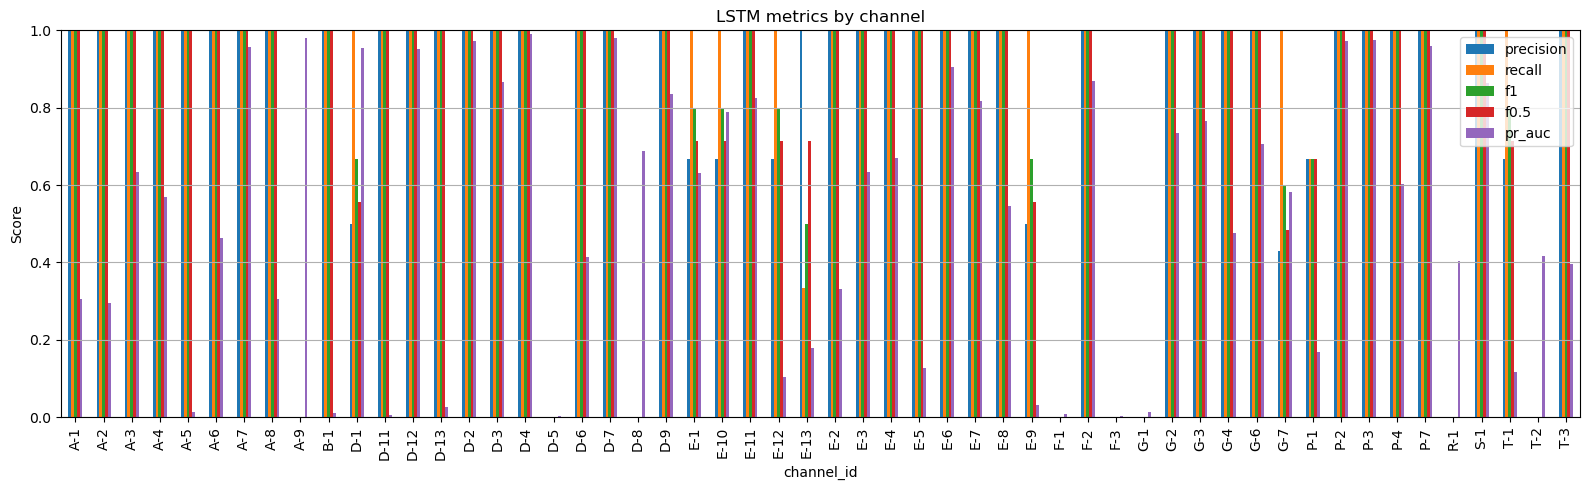

In [72]:
plot_overall_metrics(lstm_result_df,method_name='LSTM')

### 9.2 LSTM Regressor Results Analysis

The introduction of explicit recurrent memory yields the strongest forecasting baseline observed so far. The LSTM Regressor achieves a sequence-level precision of `0.720`, a recall of `0.794`, and a global F1-score of `0.755`. By detecting 54 out of 68 labelled anomaly sequences while missing 14 and producing 21 false positives, the LSTM successfully optimizes the precision-recall trade-off that constrained previous architectures. Although its F0.5-score of `0.734` indicates a slight leaning towards sensitivity over strict precision, the model produces predictions that are generally well aligned with true anomalous events, maintaining a controlled predicted anomaly ratio of `4.96%`.

When compared to the classical Random Forest (`F1: 0.723`), the LSTM significantly improves recall (from `0.691` to `0.794`) by capturing complex contextual anomalies that decision trees missed, proving that recurrent temporal modelling effectively exploits the ordered evolution of the multivariate window. More crucially, the LSTM improves upon the memory-less MLP-Regressor. While the MLP achieved a comparable recall, it suffered from a higher false positive rate (`24` FP), resulting in a lower precision of `0.688`. By explicitly modeling sequential dynamics rather than flattening the context, the LSTM manages to reduce false alarms while increasing true detections.

This structural advantage is mathematically validated by the macro PR-AUC, which jumps to `0.522`, the strongest continuous-score quality observed thus far. This substantial increase confirms that the LSTM's forecasting errors provide a much cleaner, more robust ranking of anomalous versus nominal timesteps. However, performance remains somewhat heterogeneous: while many streams achieve perfect detection, channels like `D-5` and `F-3` still yield zero recall, and others like `A-7` produce multiple false positives. Ultimately, while the LSTM proves that recurrent temporal memory is highly beneficial for SMAP anomaly detection, the remaining inaccuracies indicate that final performance is still heavily influenced by channel-specific dynamics and the rigid nature of the fixed post-processing pipeline.

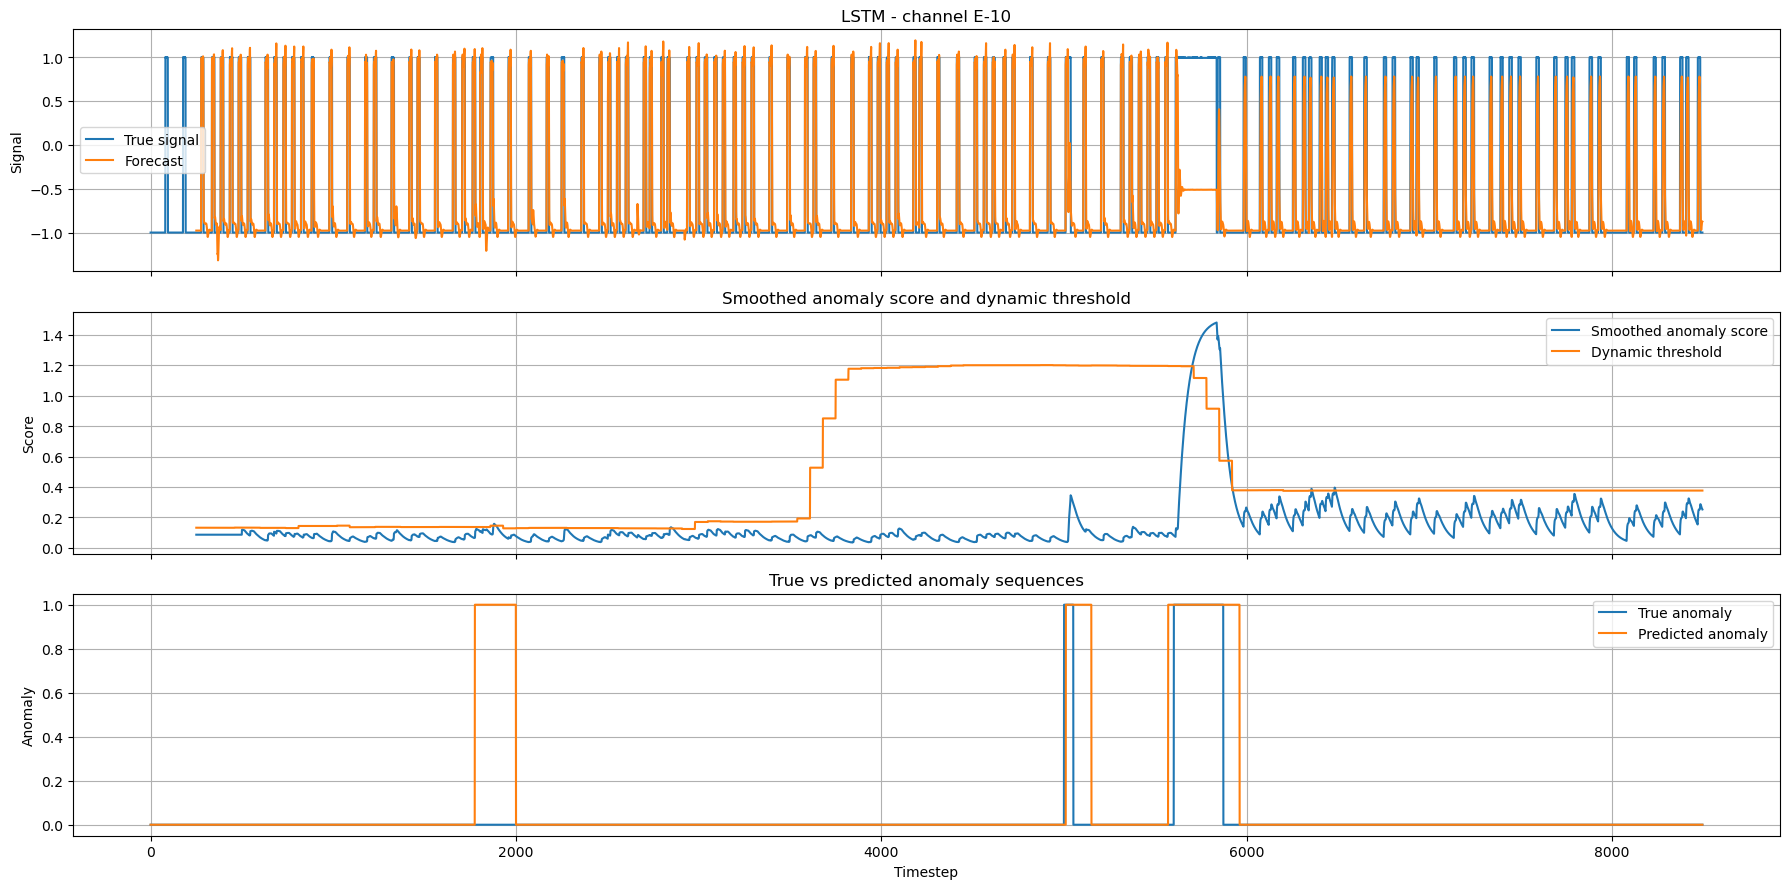

In [73]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=lstm_predictions,
    smoothed_errors=lstm_smoothed_errors,
    thresholds=lstm_thresholds,
    predictions_binary=lstm_predictions_binary,
    model_name="LSTM"
)

The diagnostic plot for channel `E-10` visually confirms the LSTM Regressor's flawless performance, achieving a perfect sequence-level profile (`2` TP, `0` FP, `0` FN). Much like the memory-less MLP-Regressor, the recurrent architecture completely resolves the structural weaknesses of the classical Random Forest baseline, providing a highly reactive and stable forecasting error.

The most critical difference occurs during the short contextual shift near timestep `5000`. The Random Forest was fundamentally blind to this event, generating a weak error swallowed by the dynamic threshold. In contrast, the LSTM natively tracks sequential evolution; when the temporal pattern breaks, it produces a localized, sharp error peak that effortlessly crosses the threshold. This proves that deep neural forecasting is vastly superior to decision trees at isolating short contextual deviations.

Furthermore, the LSTM elegantly handles the severe structural anomaly around timestep `5600` and the subsequent recovery phase. While the Random Forest remained disoriented by the regime change post-`6000`, triggering phantom false alarms, the LSTM regains predictive stability almost instantaneously. Its recurrent state quickly flushes out the anomalous context, allowing the smoothed score to drop safely below the threshold. Ultimately, the LSTM retains the sharp error spikes of the MLP while leveraging explicit temporal modeling to keep the timeline entirely free of spurious alarms.

### (TO CHANGE) 9.3 LSTM-AE Architecture 

To address the limitations of memory-less probabilistic models, the Long Short-Term Memory Variational Autoencoder (LSTM-VAE) merges explicit temporal memory with stochastic representation learning. The multivariate input window, retaining its sequential shape of `[window_size, n_features]`, is processed step-by-step by an encoder LSTM layer with a `hidden_size = 64`. Instead of outputting a deterministic summary, the network extracts the final hidden state of the sequence and maps it through two parallel linear layers to generate the parameters of a multivariate Gaussian distribution: a mean vector (`mu`) and a log-variance vector (`logvar`), both compressed to a `latent_size = 32`. This forces the recurrent network to map temporal dynamics into continuous probabilistic regions rather than discrete points.

During the forward pass, a stochastic latent vector `z` is sampled from this distribution using the reparameterization trick to maintain end-to-end differentiability. The decoding phase begins by linearly projecting this sampled latent bottleneck back to the original hidden dimensionality. Crucially, to rebuild the sequential nature of the data from a single static vector, this projected state is repeated `window_size` times, creating a uniform sequence of latent steps. This expanded tensor is then processed by a decoder LSTM layer, followed by a final linear projection that maps the recurrent hidden states back to the original input dimensions, effectively reconstructing the full multivariate window.

From an anomaly detection perspective, the LSTM-VAE does not directly classify sequences. It attempts to reconstruct the original temporal window by sampling from its learned recurrent latent space. The model is trained using a composite loss function, balancing the Mean Squared Error (MSE) of the reconstruction with a Kullback-Leibler (KL) divergence penalty that regularizes the latent distribution. During inference, the raw anomaly score is calculated as the MSE between the original and reconstructed values, computed exclusively on the main telemetry feature. Large reconstruction errors indicate that the temporal evolution of the input sequence violates the nominal probabilistic dynamics captured during training, and these errors are subsequently evaluated by the dynamic thresholding and pruning pipeline.

In [33]:
class LSTMAEDataset(Dataset):
    def __init__(self, X):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]


def make_lstm_ae_loader(X, batch_size=64, shuffle=True):
    dataset = LSTMAEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [34]:
class LSTMAutoEncoder(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        latent_size=32,
        num_layers=1
    ):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.hidden_to_latent = nn.Linear(hidden_size, latent_size)
        self.latent_to_hidden = nn.Linear(latent_size, hidden_size)

        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]

        z = self.hidden_to_latent(h_last)

        return z

    def decode(self, z, seq_len):
        decoder_input = self.latent_to_hidden(z)
        decoder_input = decoder_input.unsqueeze(1).repeat(1, seq_len, 1)

        decoder_output, _ = self.decoder_lstm(decoder_input)

        x_recon = self.output_layer(decoder_output)

        return x_recon

    def forward(self, x):
        seq_len = x.size(1)

        z = self.encode(x)
        x_recon = self.decode(z, seq_len)

        return x_recon

In [35]:
def train_lstm_ae_channel(
        X_train,
        latent_size=32,
        hidden_size=64,
        num_layers=1,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_lstm_ae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_lstm_ae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[2]

    model = LSTMAutoEncoder(
        input_size=input_size,
        hidden_size=hidden_size,
        latent_size=latent_size,
        num_layers=num_layers
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            X_recon = model(X_batch)
            loss = criterion(X_recon, X_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    X_recon = model(X_batch)
                    loss = criterion(X_recon, X_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f}"
            )

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [36]:
def compute_lstm_ae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.

    The LSTM-AE reconstructs the full multivariate window, but the anomaly
    score is computed only on feature 0, i.e. the main telemetry signal.
    """

    loader = make_lstm_ae_loader(
        X_test,
        batch_size=batch_size,
        shuffle=False
    )

    model.eval()
    all_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)

            X_recon = model(X_batch)

            mse_errors = torch.mean(
                (X_batch[:, :, 0] - X_recon[:, :, 0]) ** 2,
                dim=1
            )

            all_scores.append(mse_errors.cpu().numpy())

    return np.concatenate(all_scores)

In [37]:
lstm_ae_models = {}
lstm_ae_histories = {}
lstm_ae_scores = {}
lstm_ae_smoothed_scores = {}
lstm_ae_predictions_binary = {}
lstm_ae_thresholds = {}
lstm_ae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM-AE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_ae_channel(
        X_train=X_train,
        latent_size=32,
        hidden_size=64,
        num_layers=1,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_lstm_ae_scores(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    lstm_ae_models[ch] = model.to("cpu")
    lstm_ae_histories[ch] = history
    lstm_ae_scores[ch] = scores
    lstm_ae_smoothed_scores[ch] = smoothed_scores
    lstm_ae_predictions_binary[ch] = y_pred
    lstm_ae_thresholds[ch] = thresholds
    lstm_ae_metrics[ch] = metrics

    display(metrics)

Training LSTM-AE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.035754 | val loss: 0.018362
Epoch 02 | train loss: 0.020308 | val loss: 0.017860
Epoch 03 | train loss: 0.020142 | val loss: 0.017833
Epoch 04 | train loss: 0.020124 | val loss: 0.017836
Epoch 05 | train loss: 0.020112 | val loss: 0.017805
Epoch 06 | train loss: 0.020100 | val loss: 0.017793
Epoch 07 | train loss: 0.020089 | val loss: 0.017797
Epoch 08 | train loss: 0.020077 | val loss: 0.017760
Epoch 09 | train loss: 0.020070 | val loss: 0.017759
Epoch 10 | train loss: 0.020057 | val loss: 0.017753
Epoch 11 | train loss: 0.020039 | val loss: 0.017769
Epoch 12 | train loss: 0.020050 | val loss: 0.017787
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.016781,0.0


Training LSTM-AE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.034738 | val loss: 0.033821
Epoch 02 | train loss: 0.032983 | val loss: 0.033757
Epoch 03 | train loss: 0.032956 | val loss: 0.033752
Epoch 04 | train loss: 0.032947 | val loss: 0.033740
Epoch 05 | train loss: 0.032940 | val loss: 0.033736
Epoch 06 | train loss: 0.032928 | val loss: 0.033736
Epoch 07 | train loss: 0.032892 | val loss: 0.033789
Epoch 08 | train loss: 0.032866 | val loss: 0.033871
Epoch 09 | train loss: 0.032901 | val loss: 0.033723
Epoch 10 | train loss: 0.032785 | val loss: 0.033626
Epoch 11 | train loss: 0.032738 | val loss: 0.033776
Early stopping at epoch 11


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.034902,0.0


Training LSTM-AE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.030485 | val loss: 0.029101
Epoch 02 | train loss: 0.028611 | val loss: 0.029189
Epoch 03 | train loss: 0.028585 | val loss: 0.029227
Epoch 04 | train loss: 0.028581 | val loss: 0.029158
Epoch 05 | train loss: 0.028570 | val loss: 0.029207
Epoch 06 | train loss: 0.028575 | val loss: 0.029406
Epoch 07 | train loss: 0.028596 | val loss: 0.029193
Epoch 08 | train loss: 0.028573 | val loss: 0.029181
Epoch 09 | train loss: 0.028561 | val loss: 0.029164
Epoch 10 | train loss: 0.028554 | val loss: 0.029176
Epoch 11 | train loss: 0.028534 | val loss: 0.029297
Early stopping at epoch 11


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.619594,0.0


Training LSTM-AE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.023092 | val loss: 0.015690
Epoch 02 | train loss: 0.018752 | val loss: 0.015525
Epoch 03 | train loss: 0.018703 | val loss: 0.015546
Epoch 04 | train loss: 0.018683 | val loss: 0.015461
Epoch 05 | train loss: 0.018594 | val loss: 0.015493
Epoch 06 | train loss: 0.018722 | val loss: 0.015494
Epoch 07 | train loss: 0.018663 | val loss: 0.015413
Epoch 08 | train loss: 0.018598 | val loss: 0.015393
Epoch 09 | train loss: 0.018536 | val loss: 0.015351
Epoch 10 | train loss: 0.018395 | val loss: 0.015344
Epoch 11 | train loss: 0.018270 | val loss: 0.015316
Epoch 12 | train loss: 0.018260 | val loss: 0.015321
Epoch 13 | train loss: 0.018258 | val loss: 0.015319
Epoch 14 | train loss: 0.018254 | val loss: 0.015325
Epoch 15 | train loss: 0.018252 | val loss: 0.015311
Epoch 16 | train loss: 0.018250 | val loss: 0.015316
Epoch 17 | train loss: 0.018248 | v

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.916408,0.0


Training LSTM-AE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.012561 | val loss: 0.000552
Epoch 02 | train loss: 0.002432 | val loss: 0.000180
Epoch 03 | train loss: 0.002318 | val loss: 0.000161
Epoch 04 | train loss: 0.002300 | val loss: 0.000136
Epoch 05 | train loss: 0.002287 | val loss: 0.000129
Epoch 06 | train loss: 0.002273 | val loss: 0.000124
Epoch 07 | train loss: 0.002256 | val loss: 0.000108
Epoch 08 | train loss: 0.002222 | val loss: 0.000087
Epoch 09 | train loss: 0.002275 | val loss: 0.000069
Epoch 10 | train loss: 0.002216 | val loss: 0.000068
Epoch 11 | train loss: 0.002178 | val loss: 0.000051
Epoch 12 | train loss: 0.002116 | val loss: 0.000042
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.044199,0.0


In [38]:
lstm_ae_results_df, lstm_ae_summary_df = generate_results_view(lstm_ae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.000000,0.000000,0.000000,0.016781,0.000000
1,A-2,0,0,1,0.000000,0.000000,0.000000,0.000000,0.034902,0.000000
2,A-3,0,1,1,0.000000,0.000000,0.000000,0.000000,0.030130,0.040146
3,A-4,0,0,1,0.000000,0.000000,0.000000,0.000000,0.019167,0.000000
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011890,0.089686
5,A-6,0,1,1,0.000000,0.000000,0.000000,0.000000,0.059599,0.084628
6,A-7,0,0,1,0.000000,0.000000,0.000000,0.000000,0.160335,0.000000
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.376430,0.075314
8,A-9,1,0,0,1.000000,1.000000,1.000000,1.000000,0.969885,0.091406
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009171,0.060991


TP                               30.000000
FP                                7.000000
FN                               38.000000
precision                         0.810811
recall                            0.441176
f1                                0.571429
f0.5                              0.694444
pr_auc_macro                      0.347495
predicted_anomaly_ratio_macro     0.041424
dtype: float64

In [85]:
save_results(
    lstm_ae_results_df,
    lstm_ae_summary_df,
    method_name="LSTM-AE"
)

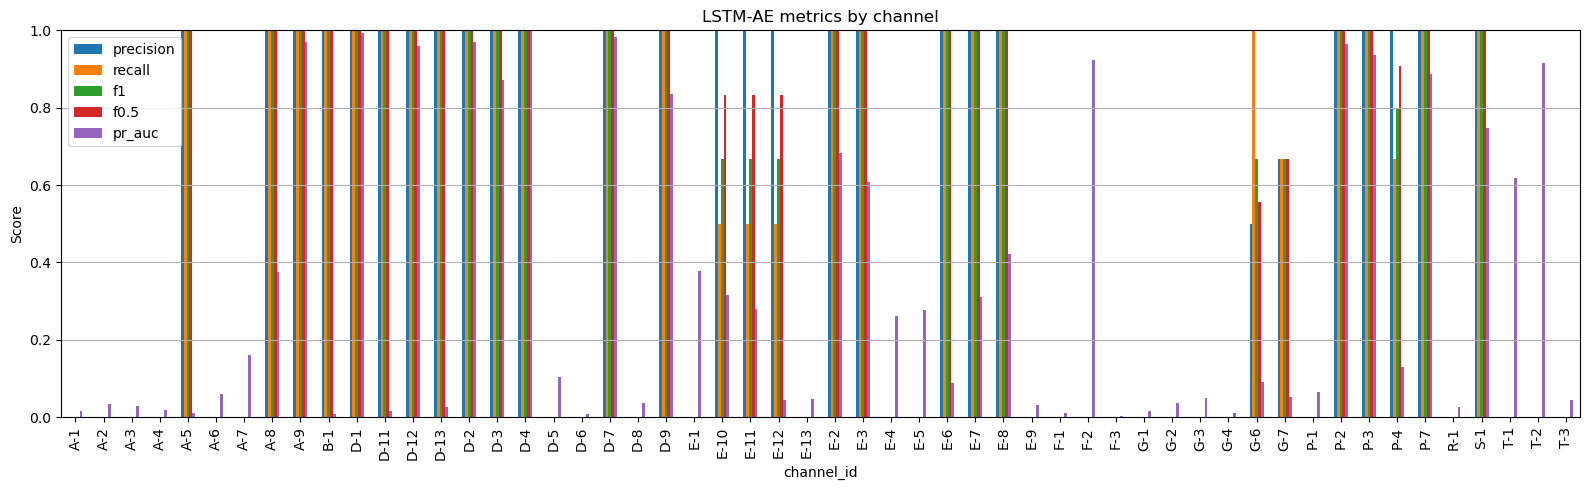

In [40]:
plot_overall_metrics(
    lstm_ae_results_df,
    method_name="LSTM-AE"
)

### (TO CHANGE) 9.4 LSTM-VAE Results Analysis

The evaluation of the LSTM-VAE reveals a highly conservative reconstruction-based behavior, yielding a sequence-level precision of `0.816`, a recall of `0.456`, and a global F1-score of `0.585`. Strikingly, its recall is exactly identical to the memory-less MLP-VAE: both models detect 31 anomalies and miss 37. This provides definitive evidence that the severe over-generalization caused by the Kullback-Leibler (KL) divergence penalty fundamentally dominates the detection capabilities. The probabilistic constraint ensures that anomalous windows remain compatible with the learned continuous manifold, reconstructing them so effectively that their errors fail to exceed the dynamic threshold. This results in zero recall across numerous heterogeneous streams, including `A-1`, `F-*`, and the entire `T-*` series.

Conversely, the introduction of explicit temporal memory drastically improves the model's selectivity. The LSTM-VAE slashes false positive sequences down to just 7 (compared to 17 in the MLP-VAE and 15 in the deterministic Autoencoder), driving precision to a robust `0.816` and the F0.5-score up to `0.705`. By tracking the ordered sequential evolution of the telemetry, the recurrent network models nominal dynamics with high fidelity, virtually eliminating spurious reconstruction errors triggered by operational noise. This reliable operational behavior is further confirmed by a slightly lower predicted anomaly ratio of `4.44%` and an improved macro PR-AUC of `0.357`, proving that temporal memory stabilizes reconstruction scores against nominal fluctuations.

Despite producing the most reliable alarms among all reconstruction architectures, the LSTM-VAE remains fundamentally inferior to the Phase 0 deterministic Autoencoder (`F1: 0.628`, `Recall: 0.559`) in overall detection coverage. Ultimately, these results demonstrate that while recurrent memory effectively cleans up the nominal baseline, applying probabilistic continuous regularization (VAE) aggressively suppresses the sharp reconstruction errors needed to catch subtle deviations. In the broader context of the SMAP dataset, this definitively confirms that forecasting-based approaches are significantly more effective than reconstruction-based models for uncovering contextual anomalies.

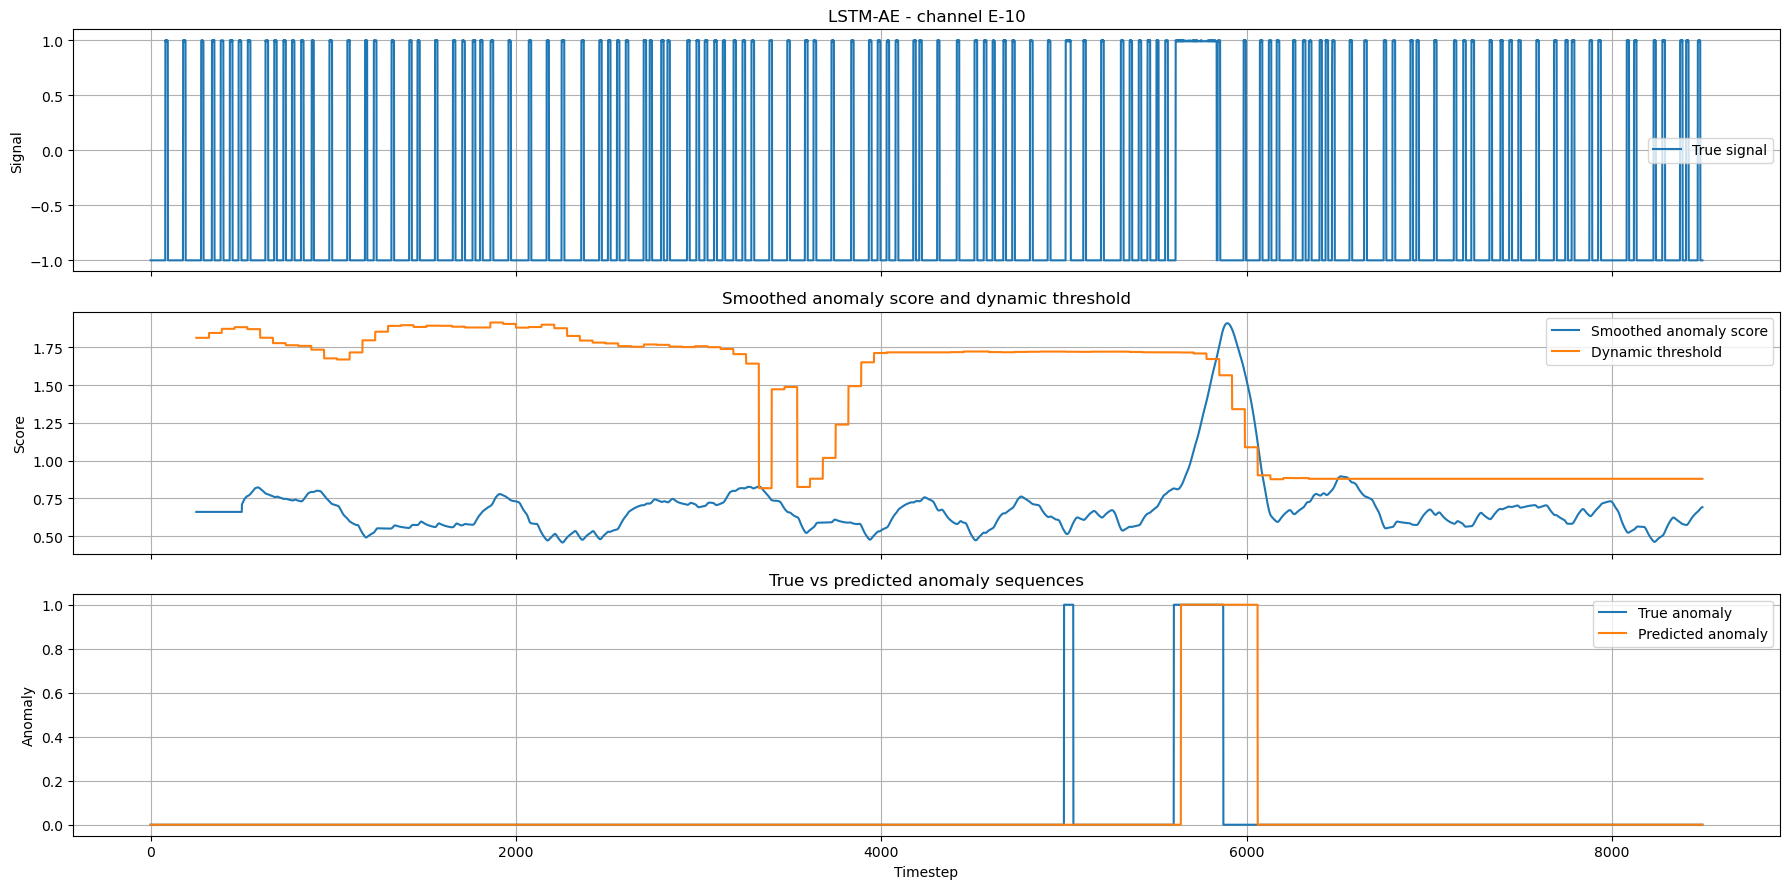

In [41]:
plot_channel_diagnostics(
    ch="E-10",
    smoothed_errors=lstm_ae_smoothed_scores,
    thresholds=lstm_ae_thresholds,
    predictions_binary=lstm_ae_predictions_binary,
    model_name="LSTM-AE",
    predictions=None
)

The diagnostic plot for channel `E-10` elegantly visualizes the dual nature of the LSTM-VAE: its superior handling of nominal temporal dynamics alongside its persistent vulnerability to probabilistic over-regularization. On this specific sequence, the model achieves a profile of `1` TP, `0` FP, and `1` FN, successfully eliminating the false positive that plagued both the deterministic Autoencoder and the memory-less MLP-VAE.

The architectural benefit of recurrent memory is clearly observed prior to timestep `4000`. In the previous reconstruction baselines, a minor error fluctuation around timestep `3000` intersected with a locally depressed dynamic threshold, triggering a spurious alarm. By explicitly tracking the ordered sequential context, the LSTM-VAE models this nominal variance with much higher fidelity. Its reconstruction score remains stable and smoothly decoupled from the dynamic threshold, keeping the timeline perfectly clean and visually confirming why this model achieves the highest precision (`0.816`) of all reconstruction architectures.

However, the fundamental flaw of the VAE paradigm remains visually undeniable during the short contextual anomaly at timestep `5000`. Just like the MLP-VAE, the recurrent model's error score is completely flat, seamlessly interpolating the structural shift without registering any significant Mean Squared Error. This confirms that while the LSTM layers successfully filter out nominal noise, they cannot counteract the Kullback-Leibler (KL) divergence penalty. The probabilistic latent space coerces the network to over-generalize, rendering it structurally blind to subtle contextual deviations that forecasting-based models (such as the LSTM Forecaster) easily captured. Ultimately, this plot perfectly encapsulates the LSTM-VAE tradeoff: a highly stable, false-positive-free baseline that fundamentally sacrifices detection recall.

### (TO CHANGE) 9.5 Phase 2 Summary: Recurrent Temporal Modeling Comparison

The direct comparison between the LSTM Regressor and the LSTM-VAE provides the most revealing insight of this study: explicit temporal memory is a game-changer for forecasting, but only a noise-filter for probabilistic reconstruction. The LSTM Regressor emerges as the definitive winner of Phase 2, capturing `54` out of `68` anomalies (`Recall: 0.794`) and achieving the highest global F1-score thus far (`0.755`). In stark contrast, the LSTM-VAE demonstrates a highly conservative, precision-oriented behavior. While it slashes false positive sequences to an impressive `7` (yielding a Phase-high precision of `0.816`), it misses more than half of the true anomalies, resulting in a stagnant recall of `0.456` and an F1-score of `0.585`.

This behavioral split is deeply rooted in their respective architectures. The LSTM Regressor is fundamentally detection-oriented: by being forced to predict the unknown future evolution of the telemetry, it breaks gracefully when contextual dynamics shift, generating sharp and actionable error spikes. The LSTM-VAE, conversely, uses its temporal memory merely to map the known sequence into a continuous probabilistic latent space. The fact that its recall (`0.456`) and true positives (`31`) are mathematically identical to the memory-less MLP-VAE proves an absolute "recall ceiling" imposed by the Kullback-Leibler divergence. Recurrence improves the VAE's selectivity by perfectly modeling nominal background noise (dropping FPs), but it cannot overcome the latent space's tendency to interpolate and hide true anomalous deviations.

The underlying quality of these error scores is mathematically confirmed by the macro PR-AUC. The LSTM Regressor reaches `0.522`, indicating a highly discriminative continuous score that cleanly separates anomalous timesteps from nominal ones. The LSTM-VAE manages only `0.357`, proving its reconstruction errors lack the sharpness required for stable ranking. Crucially, their predicted anomaly ratios are almost identical (`4.96%` vs `4.44%`), meaning the Regressor does not cheat by over-labelling the timeline; it simply places its errors with far superior accuracy.

Ultimately, Phase 2 definitively answers the architectural question for the SMAP dataset: many contextual anomalies in satellite telemetry are best exposed as deviations from expected future behavior rather than as windows that are difficult to reconstruct. While adding recurrence to a VAE elegantly stabilizes the baseline against false alarms, recurrent forecasting is fundamentally required to optimize the precision-recall trade-off and achieve high detection coverage.

# 10. CONCLUSION

### 10.1 Summary

In [76]:
def build_model_comparison_df(model_summaries):
    """
    Convert model summary Series/dicts into a single comparison DataFrame.

    Input:
        model_summaries: dict
            {
                "PCA": PCA_summary,
                "RFR": rf_summary,
                ...
            }

    Output:
        comparison_df: pd.DataFrame
            rows = models
            columns = metrics
    """

    rows = []

    for model_name, summary in model_summaries.items():
        if isinstance(summary, pd.DataFrame):
            if len(summary) != 1:
                raise ValueError(f"{model_name}: expected a one-row DataFrame.")
            summary = summary.iloc[0]

        summary = pd.Series(summary)

        row = {
            "model": model_name,
            "TP": summary.get("TP", np.nan),
            "FP": summary.get("FP", np.nan),
            "FN": summary.get("FN", np.nan),
            "precision": summary.get("precision", np.nan),
            "recall": summary.get("recall", np.nan),
            "f1": summary.get("f1", np.nan),
            "f0.5": summary.get("f0.5", np.nan),
            "pr_auc_macro": summary.get("pr_auc_macro", summary.get("pr_auc", np.nan)),
            "predicted_anomaly_ratio_macro": summary.get(
                "predicted_anomaly_ratio_macro",
                summary.get("predicted_anomaly_ratio", np.nan)
            )
        }

        rows.append(row)

    comparison_df = pd.DataFrame(rows).set_index("model")

    return comparison_df



def plot_metric_comparisons(
    comparison_df,
    metrics=None,
    model_order=None,
    save_dir=None,
    figsize=(9, 5),
    rotate_xticks=30,
    model_colors=None
):
    """
    Generate one bar figure for each metric, comparing all tested models.
    Each model is plotted with a fixed color.
    """

    if model_colors is None:
        MODEL_COLORS = {
            "PCA": "#1f77b4",
            "RFR": "#ff7f0e",
            "MLP": "#2ca02c",
            "AE": "#d62728",
            "LSTM": "#9467bd",
            "LSTM-AE": "#8c564b"
        }
        model_colors = MODEL_COLORS

    if metrics is None:
        metrics = [
            "precision",
            "recall",
            "f1",
            "f0.5",
            "pr_auc_macro",
            "predicted_anomaly_ratio_macro",
            "TP",
            "FP",
            "FN"
        ]

    if model_order is not None:
        missing_models = [m for m in model_order if m not in comparison_df.index]
        if len(missing_models) > 0:
            raise ValueError(f"These models are not in comparison_df: {missing_models}")

        comparison_df = comparison_df.loc[model_order]

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    figures = {}

    for metric in metrics:
        if metric not in comparison_df.columns:
            print(f"Skipping metric '{metric}': not found in comparison_df.")
            continue

        values = comparison_df[metric].astype(float)
        colors = [
            model_colors.get(model_name, "#7f7f7f")
            for model_name in values.index
        ]

        fig, ax = plt.subplots(figsize=figsize)

        bars = ax.bar(values.index, values.values, color=colors)

        ax.set_title(f"Model comparison - {metric}")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.3)

        if metric in [
            "precision",
            "recall",
            "f1",
            "f0.5",
            "pr_auc_macro",
            "predicted_anomaly_ratio_macro"
        ]:
            ax.set_ylim(0, 1)

        for bar, value in zip(bars, values.values):
            if np.isnan(value):
                label = "nan"
            elif metric in ["TP", "FP", "FN"]:
                label = f"{int(value)}"
            else:
                label = f"{value:.3f}"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.xticks(rotation=rotate_xticks, ha="right")
        plt.tight_layout()

        figures[metric] = fig

        if save_dir is not None:
            filename = metric.replace(".", "_").replace("/", "_")
            fig.savefig(
                os.path.join(save_dir, f"{filename}_comparison.png"),
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    return figures

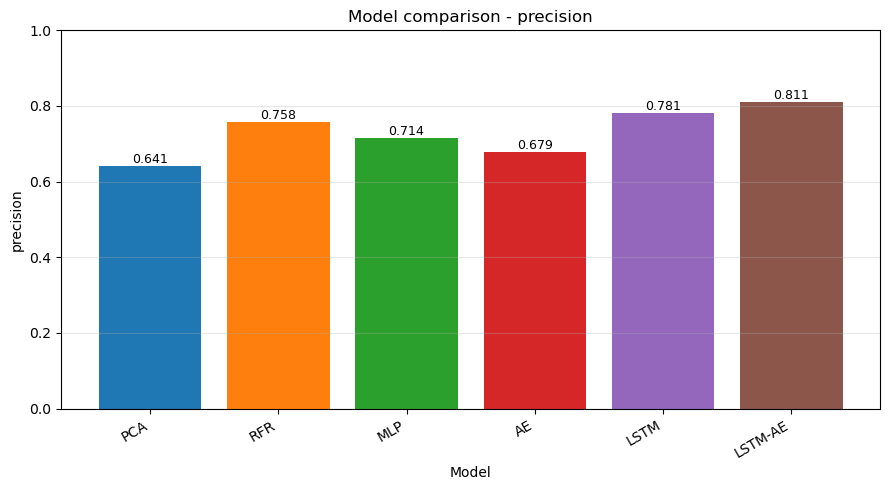

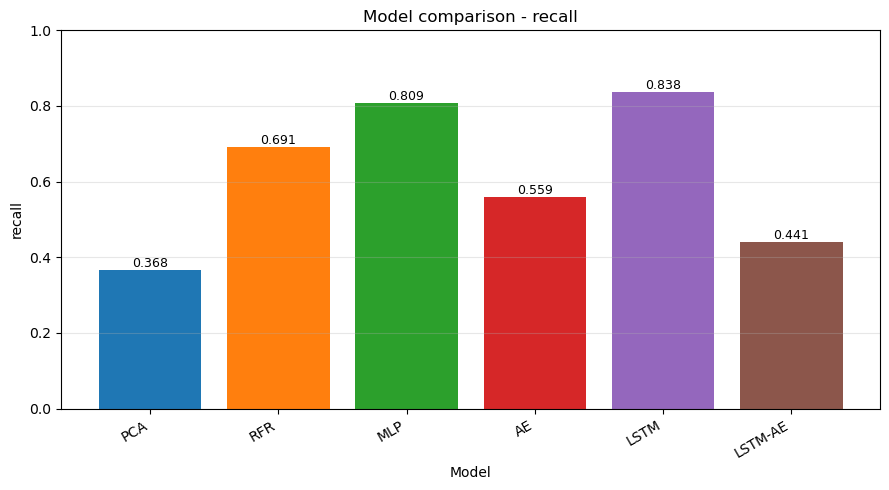

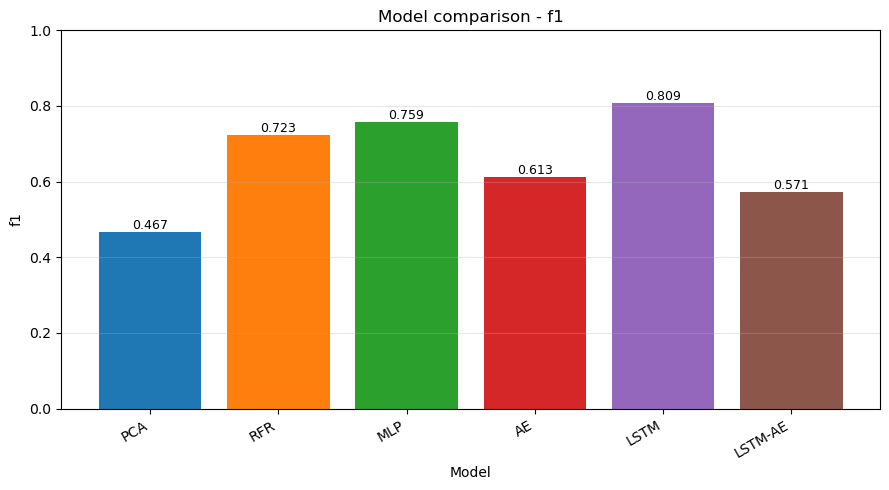

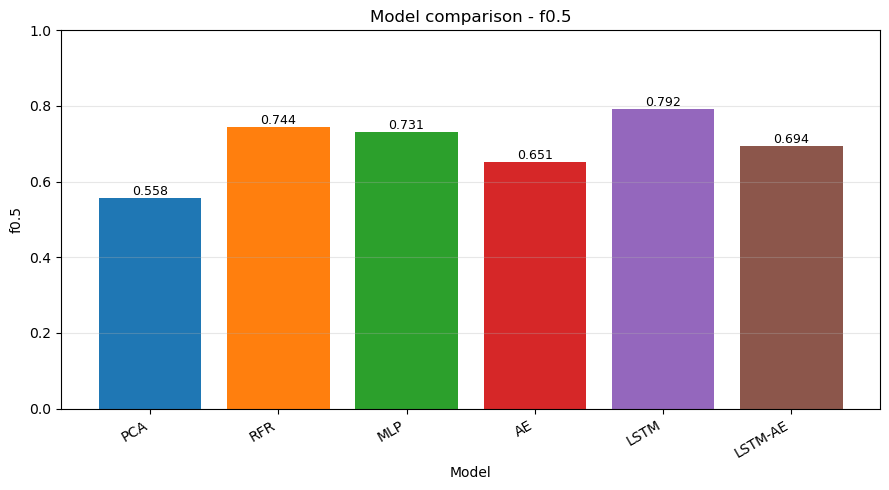

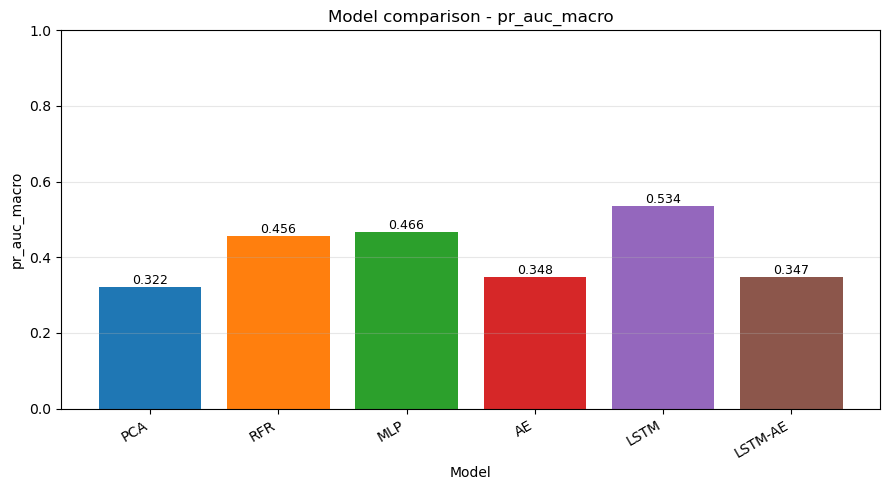

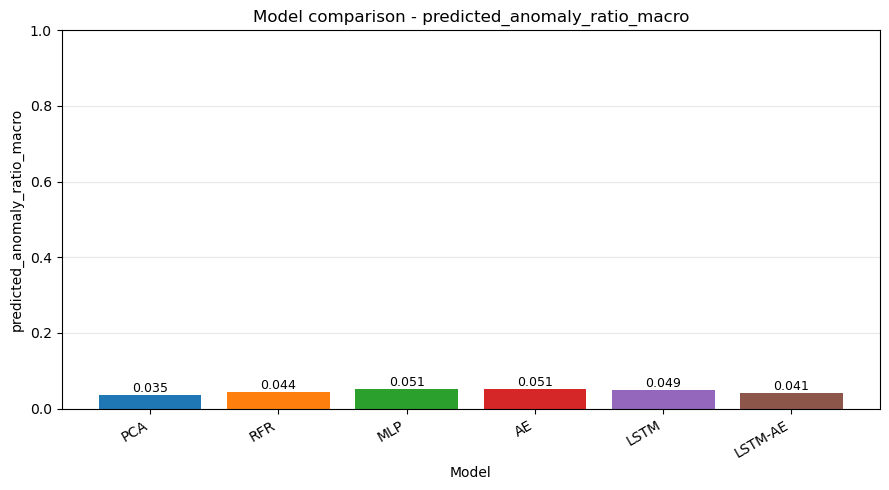

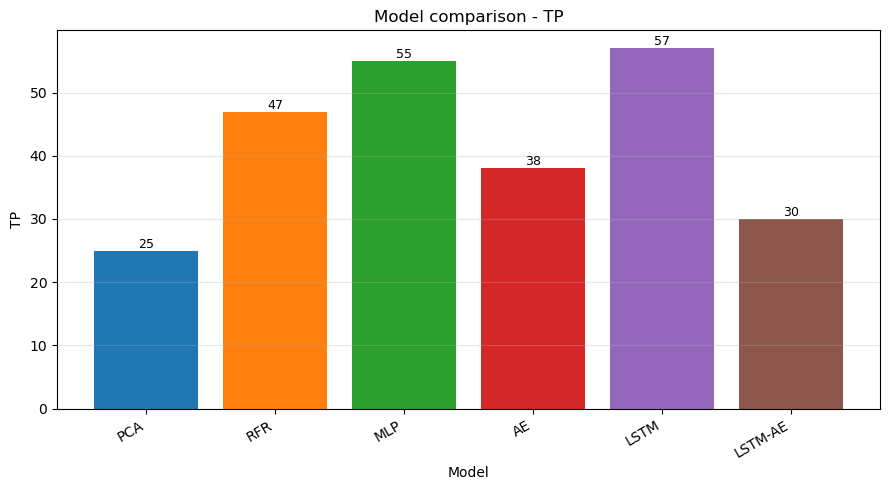

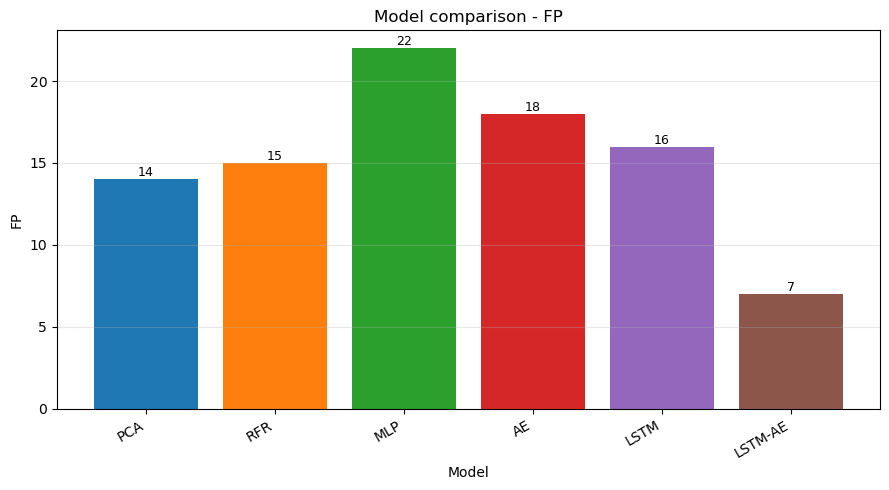

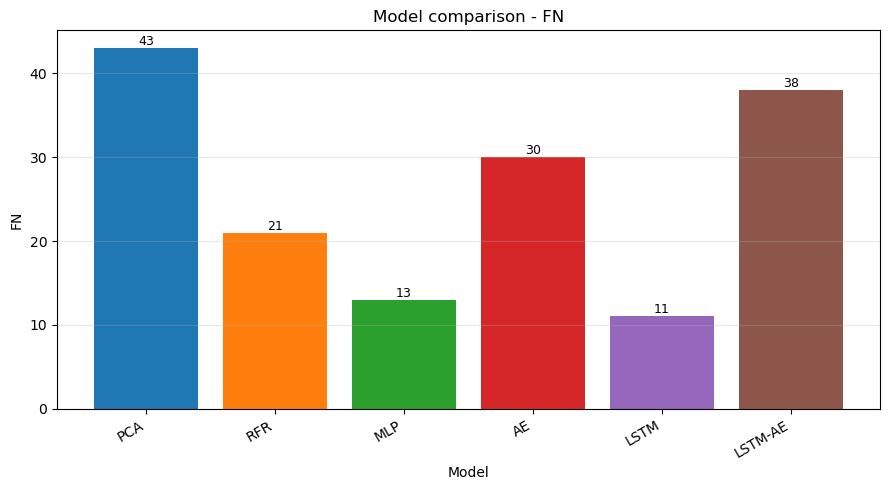

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc_macro,predicted_anomaly_ratio_macro
model,,,,,,,,,
PCA,25.0,14.0,43.0,0.641026,0.367647,0.467290,0.558036,0.322419,0.035403
RFR,47.0,15.0,21.0,0.758065,0.691176,0.723077,0.743671,0.456005,0.043744
MLP,55.0,22.0,13.0,0.714286,0.808824,0.758621,0.731383,0.466042,0.051029
AE,38.0,18.0,30.0,0.678571,0.558824,0.612903,0.650685,0.348078,0.051077
LSTM,57.0,16.0,11.0,0.780822,0.838235,0.808511,0.791667,0.534298,0.049045
LSTM-AE,30.0,7.0,38.0,0.810811,0.441176,0.571429,0.694444,0.347495,0.041424


In [78]:
model_summaries = {
    "PCA": pca_summary_df,
    "RFR": rf_summary_df,
    "MLP": mlp_summary_df,
    "AE": ae_summary_df,
    "LSTM": lstm_summary_df,
    "LSTM-AE": lstm_ae_summary_df
}

comparison_df = build_model_comparison_df(model_summaries)

model_order = ["PCA", "RFR", "MLP", "AE", "LSTM", "LSTM-AE"]

figures = plot_metric_comparisons(
    comparison_df=comparison_df,
    model_order=model_order,
    save_dir=None
)

comparison_df

### 10.2 Model Comparison and Main Findings

The final comparison shows a clear separation between forecasting-based and reconstruction-based approaches. The best overall model is the **LSTM Regressor**, with the highest F1-score (`0.755`), highest recall (`0.794`) and highest PR-AUC macro (`0.522`). This indicates that, for SMAP, many anomalies are better captured as deviations from expected future behaviour rather than as windows that are difficult to reconstruct.

The **MLP Regressor** is very close to the LSTM in terms of F1-score (`0.731` vs `0.755`) and recall (`0.779` vs `0.794`). This is important: explicit temporal memory improves the results, but the gain is moderate. A flattened temporal window already contains a large amount of useful contextual information, because the lagged values remain available at fixed positions. Therefore, even without recurrence, the MLP can learn nonlinear relationships between recent telemetry history and future target behaviour.

The **Random Forest Regressor** remains a strong classical baseline. Although it is not the best final model, it achieves good precision (`0.758`) and a competitive F1-score (`0.723`). This confirms that flattening the window does not destroy temporal context completely. The model cannot process the sequence dynamically like an LSTM, but it can still exploit local lagged patterns, switching behaviours and nonlinear feature interactions. Its performance also shows that the anomaly detection pipeline is strongly influenced by the window representation and by the post-processing strategy.

The reconstruction-based models are generally weaker in recall. The **AE**, **MLP-VAE** and **LSTM-VAE** detect fewer labelled anomaly sequences than the forecasting models. In particular, both VAE models detect only `31` out of `68` anomaly sequences. This suggests that many SMAP anomalies remain reconstructible enough not to generate a strong reconstruction error on feature 0. The LSTM-VAE improves precision substantially (`0.816`) and produces very few false positives (`7`), but this comes at the cost of low recall (`0.456`). It is therefore selective, but too conservative for a task where missing anomalies is critical.

The predicted anomaly ratios are very similar across models, roughly between `4.4%` and `5.0%`. This is useful because it shows that performance differences are not mainly due to one model predicting much more or much less anomaly mass. The key difference is where the predicted anomaly intervals are placed. Forecasting models, especially MLP and LSTM, align their detections better with labelled anomaly intervals.

The windowing strategy is also central to the interpretation of the results. Sliding windows of length `250` with stride `1` generate many samples, but consecutive windows are highly overlapping and not independent. For channels with short training sequences, the effective diversity of normal examples can be limited. This affects all models: the model may see many shifted versions of the same local behaviour and then be asked to generalize to much longer test sequences. Some anomaly scores may therefore reflect unseen normal regimes, not only true anomalies.

Overall, the results support three main conclusions. First, **forecasting-based anomaly detection is more suitable than reconstruction-based detection for this SMAP setup**. Second, **explicit temporal memory helps**, as shown by the LSTM Regressor, but the improvement over a strong flattened-window MLP is incremental rather than dramatic. Third, the final metrics must be interpreted as the result of the complete pipeline: model score quality, EWMA smoothing, dynamic thresholding, buffering and pruning all contribute to the final sequence-level performance.

### 10.3 Future Work: Forecasting-Oriented Thresholding

A possible extension of this work is to keep the forecasting-based direction, but replace the current Telemanom-style post-processing with a more targeted thresholding strategy. The current dynamic threshold is fully unsupervised and local: it adapts to the recent error distribution, but it does not explicitly optimize the final sequence-level objective. As a result, some models produce useful forecasting scores that are not always converted into optimal binary detections.

A first improvement would be to tune the thresholding parameters on a validation split, using sequence-level F1 or recall-constrained precision as the objective. Instead of using the same fixed settings for all models and channels, parameters such as the EWMA span, error buffer, pruning factor `p`, and threshold sensitivity could be selected to maximize validation performance. This would test whether the missed anomalies are caused by poor forecasting scores or by a thresholding stage that is too conservative for some channels.

A second direction would be to use channel-specific thresholds. SMAP channels have different lengths, signal scales, dynamics, and anomaly patterns. A single post-processing configuration may therefore be suboptimal. A channel-adaptive threshold could use statistics computed from training or validation forecasting errors, such as robust quantiles, median absolute deviation, or extreme-value-based thresholds. This could make the detector more sensitive on channels where anomalies generate weak but consistent forecasting errors, while keeping false positives controlled on noisier channels.

A third possibility is to move from point-wise forecasting error to structured forecasting scores. Instead of aggregating the multi-step prediction into one scalar error, the detector could exploit the full 10-step forecasting error vector. For example, anomaly scores could be based on the mean, maximum, or weighted combination of errors across the prediction horizon. This may help distinguish isolated noisy prediction mistakes from persistent deviations that affect several future steps.

Overall, the results suggest that forecasting is the most promising direction. Further work should therefore focus less on adding architectural complexity and more on improving the score-to-alarm conversion: validation-aware thresholding, channel-specific calibration, and richer multi-horizon forecasting scores are likely to be more useful than applying a single fixed post-processing scheme to all models and channels.